# Predicting Loan Repayments with Decision Trees and Random Forest

We will use decision tree and random forest models to predict whether a lender is likely to repay their loan.

## About the Data
We will use publicly available data from [LendingClub.com](www.lendingclub.com), a lending platform that connects borrowers with investors. 

The following summarizes the features in the data:
- **credit.policy**: whether the customer meets the credit criteria (1 if yes, 0 if no)
- **purpose**: the purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other")
- **int.rate**: the interest rate of the loan; borrowers deemed more risky are assigned higher interest rates
- **installment**: monthly installments owed by the borrower if the loan is funded
- **log.annual.inc**: natural log of the self-reported annual income of the borrower
- **dti**: debt-to-income ratio of the borrower
- **fico**: FICO credit score of the borrower
- **days.with.cr.line**: number of days the borrower has had a credit line
- **revol.bal**: borrower's revolving balance (amount unpaid at the end of the credit card billing cycle)
- **revol.util**: borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available)
- **inq.last.6mths**: borrower's number of inquiries by creditors in the last 6 months
- **delinq.2yrs**: number of times the borrower has been 30+ days past due on a payment in the past 2 years
- **pub.rec**: borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments)
- **not.fully.paid**: whether the customer has failed to fully pay their loan (1 if yes, 0 if no)

## Step 1: Load Packages and Data
We'll start by loading the Python packages that we'll need along with the data.

In [215]:
# math and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_curve, roc_auc_score, recall_score, precision_score, f1_score

%matplotlib inline
pd.set_option('display.width', 200)

In [5]:
df = pd.read_csv('./data/loan_data.csv')

## Step 2: Exploratory Data Analysis

Next, we'll perform Exploratory Data Analysis (EDA) to obtain a deeper understanding of the data. EDA is essential for identifying patterns, outliers, correlations, and potential data quality issues. Our EDA will focus on the following:

- Review basic summary statistics to understand the central tendency and scale of numerical variables
- Visualize feature distributions to help identify skewed distributions or outliers
- Check for missing values, invalid entries, or duplicate samples
- Inspect the target variable's distribution to identify any class imbalance

### Step 2.1: Basic Summary Statistics
We'll use `panda`'s `df.info()` function to see a high-level summary of each column and `df.describe()` function to review a summary of basic statistics of the numerical variables.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9574 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9549 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9516 non-null   float64
 10  inq.last.6mths     9549 non-null   float64
 11  delinq.2yrs        9549 non-null   float64
 12  pub.rec            9549 non-null   float64
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(9), int64(4), object(1)
memory usage: 1.0+ MB


In [9]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9574.000000,9578.000000,9578.000000,9549.000000,9.578000e+03,9516.000000,9549.000000,9549.000000,9549.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.931874,12.606679,710.846314,4562.026085,1.691396e+04,46.865677,1.571578,0.163787,0.062101,0.160054
std,0.396245,0.026847,207.071301,0.614736,6.883970,37.970537,2497.985733,3.375619e+04,29.018642,2.198095,0.546712,0.262152,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.700000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.927987,12.665000,707.000000,4139.958333,8.596000e+03,46.400000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.289832,17.950000,737.000000,5730.000000,1.824950e+04,71.000000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


There are a total of 9,578 data samples with 9 float columns, 4 integer columns, and 1 object column. We can see that some columns have less than the maximum number of data samples, which suggests that there are data quality issues such as missing data that need addressing. The object column will likely need to be encoded to a numerical feature to be properly used by the model. The float and integer features have a wide range in central tendency and distribution width. Typically, this would suggest the need for feature scaling. However, decision tree and random forest models are generally not sensitive to scale. 

### Step 2.2: Visualize Feature Distributions
Now we will visualize the distribution of features, which is a simple yet effective way to identify data quality issues such as skewed distributions, missing data, and outliers.

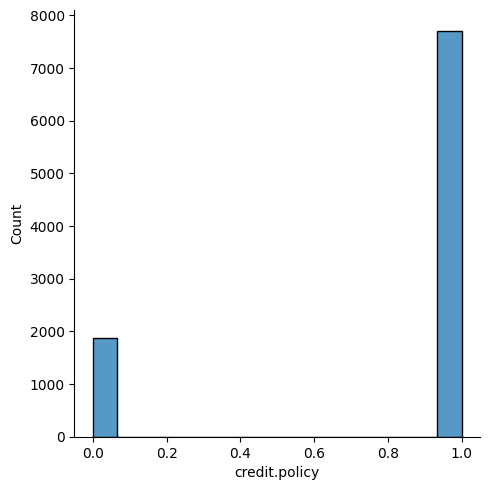

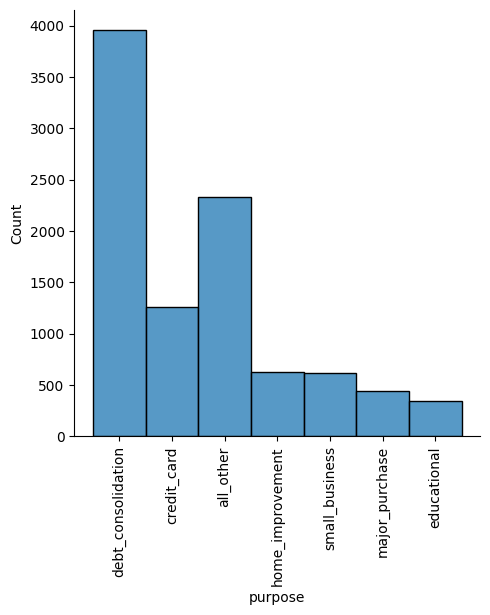

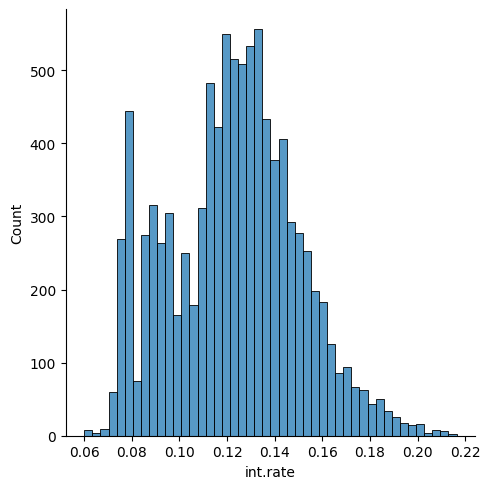

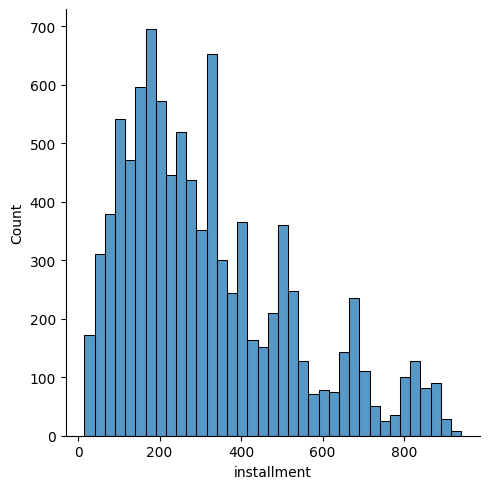

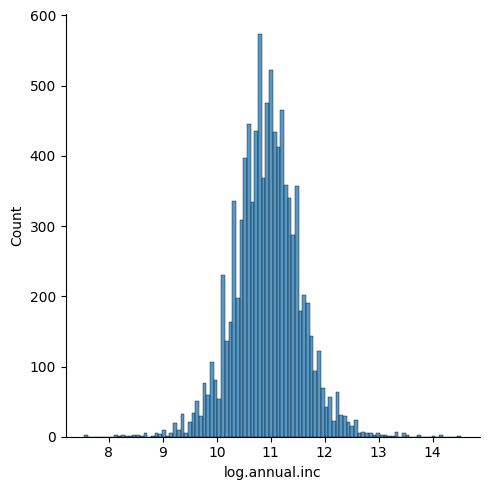

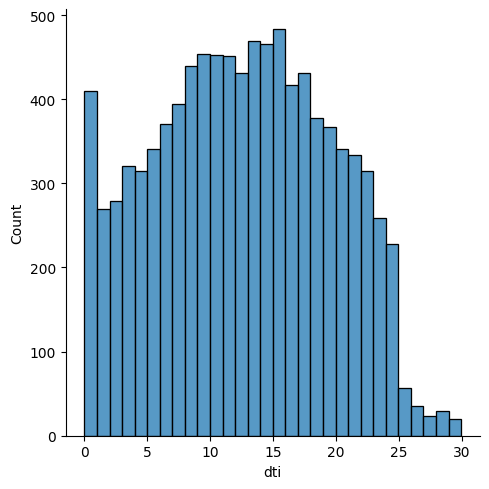

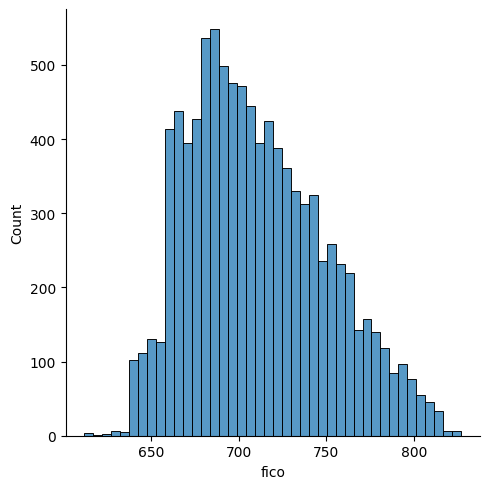

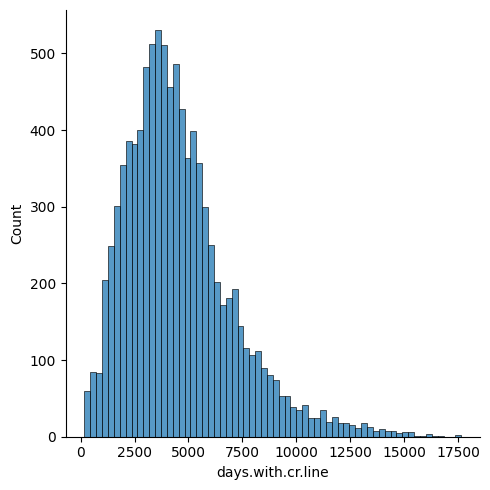

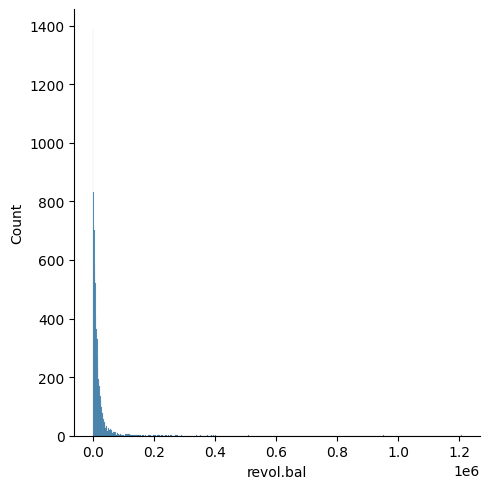

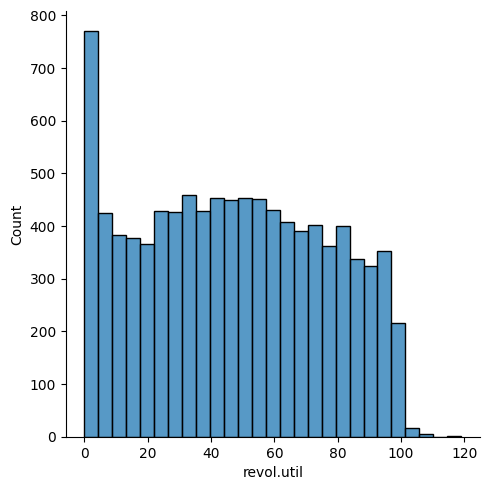

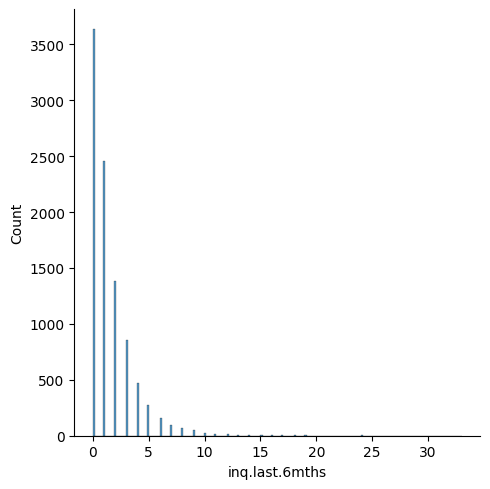

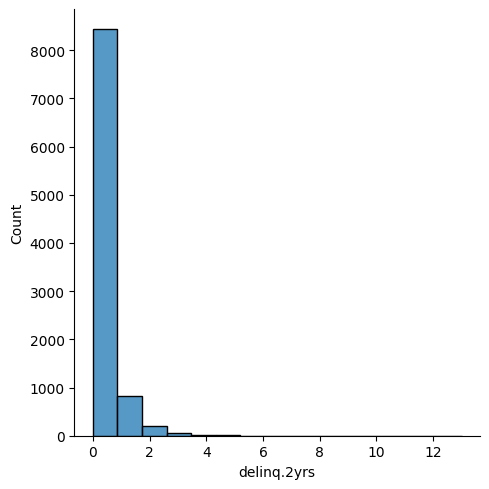

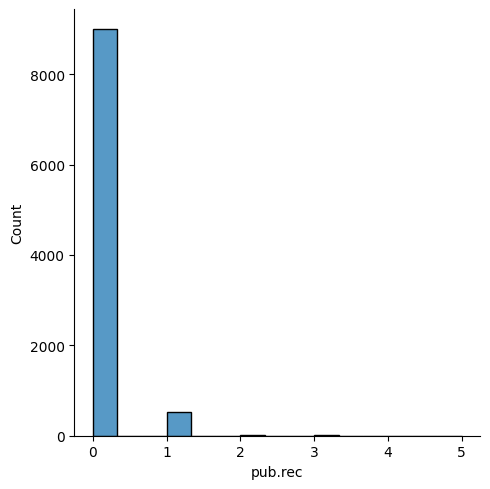

In [12]:
# plot the distributions
for col in df.drop(columns=['not.fully.paid']).columns:
    sns.displot(data=df,x=col)
    # rotate x axis labels
    if col=='purpose':
        plt.xticks(rotation=90)
plt.show()

### Step 2.3: Visualize Target Variable Distributions
Let's now take a look at the distribution of the target variable, `not.fully.paid`.

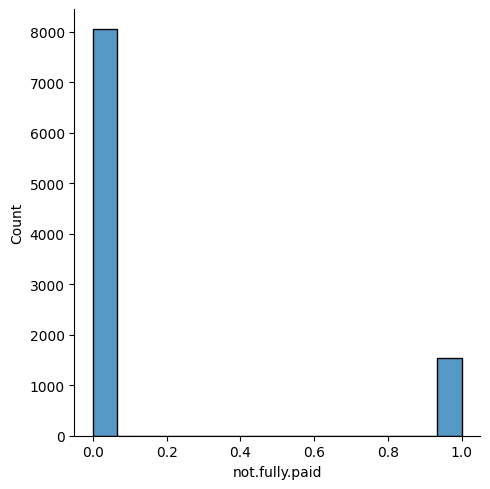

In [14]:
# plot the distribution
sns.displot(data=df,x='not.fully.paid')
plt.show()

In [15]:
# inspect the underlying data of the target variable distribution
print(df['not.fully.paid'].value_counts())

print(f"The ratio of 'not.fully.paid' class labels 0/1: {(df['not.fully.paid']==0).sum()/(df['not.fully.paid']==1).sum()}")
print(f"The ratio of positive class labels to total samples: {(df['not.fully.paid']==1).sum()/len(df)}")

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64
The ratio of 'not.fully.paid' class labels 0/1: 5.247879973907371
The ratio of positive class labels to total samples: 0.16005429108373356


The distributions of `not.fully.paid` reveals a strong class imbalance: only 16% of individuals have defaulted on their loans, meaning that those who have fully paid back their loans are five times as likely compared to those who have defaulted. This magnitude of class imbalance could cause the decision tree and random forest models to predict more negative classes to achieve a higher accuracy score, which can cause them underperform on recall for the minority class. Correctly identifying borrowers who are likely to default on their loan should be prioritized overall accuracy and will be a key driver when considering model performance and selection.

### Step 2.4. Visualize Feature Relationships
We'll now visualize the relationships between numerical features and the target variable as well as the relationships between the features themselves.

We'll start by creating a pairplot using Seaborn's `sns.pairplot()` function, which shows scatterplots between different features on the off-diagonal elements and distributions of each feature along the diagonal elements. Coloring the points by loan repayment status (`not.fully.paid`) can help us identify patterns, separability, or nonlinear relationships between features, which can be useful in understanding how well tree-based models might perform on this dataset.

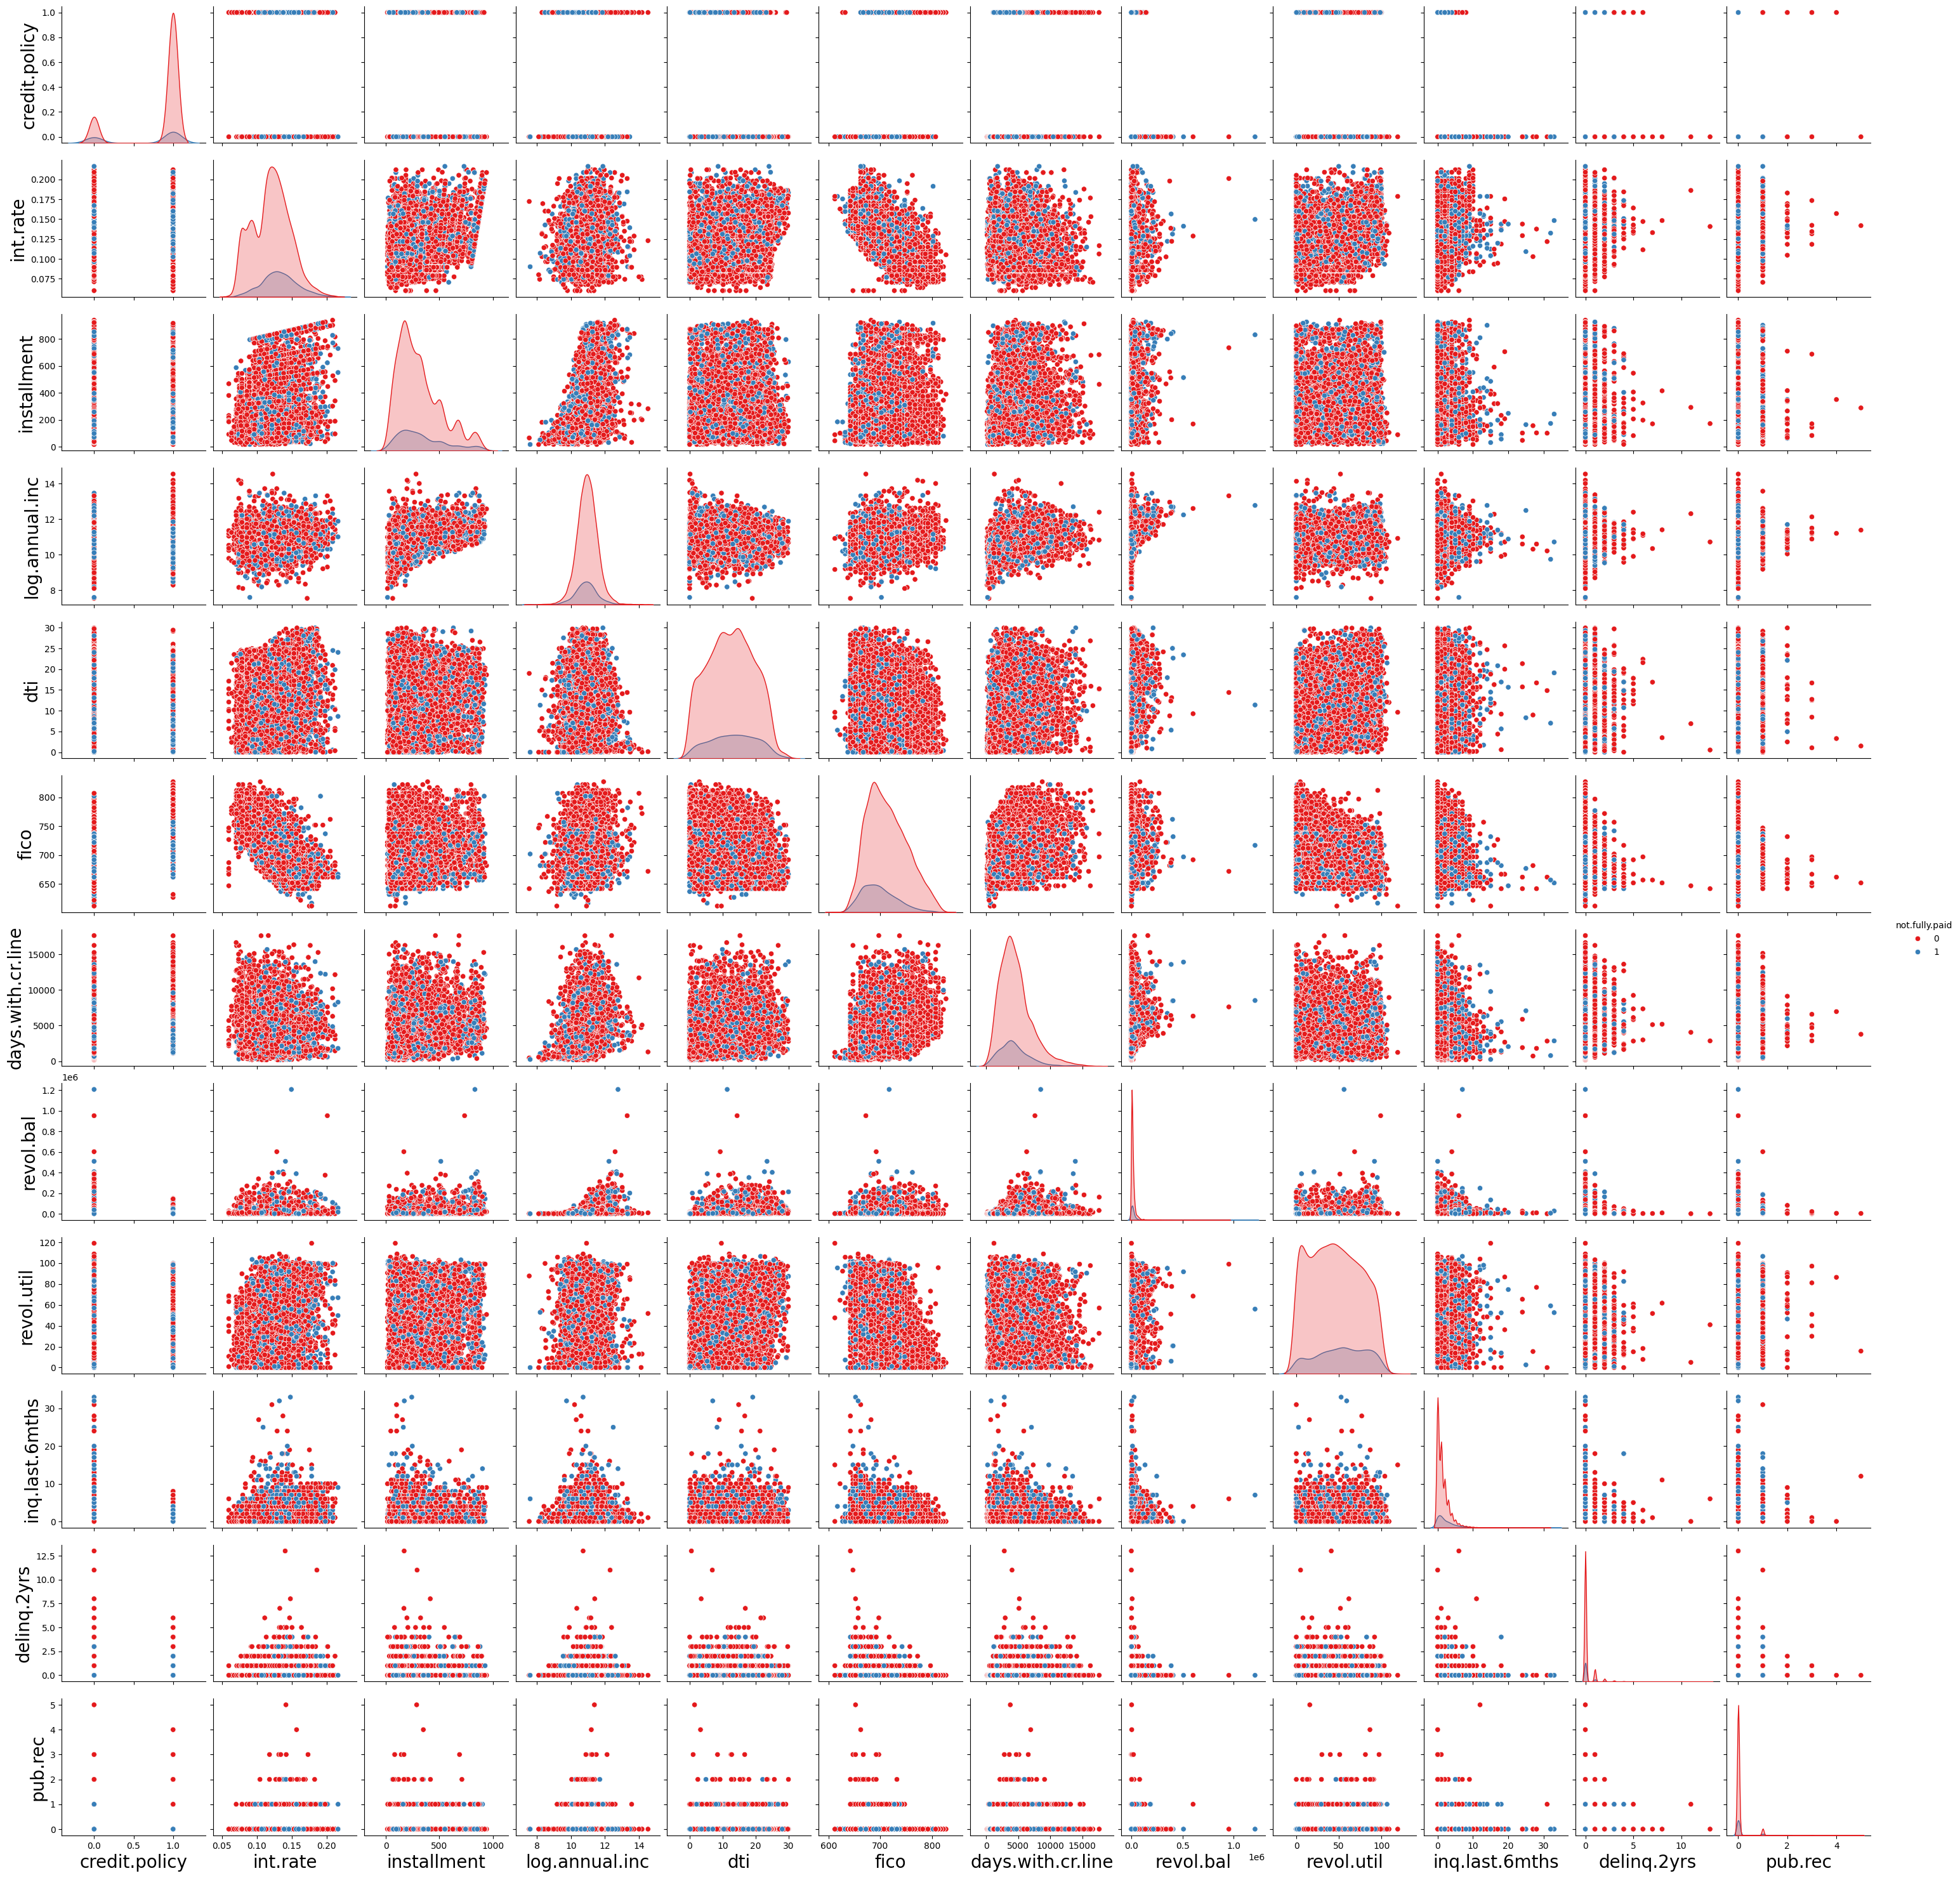

In [18]:
# create pairplot
fig = sns.pairplot(data=df,hue='not.fully.paid',palette='Set1')
# Loop through all axes and make labels bigger
for ax in fig.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=20)
        ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.show()

This reveals that `int.rate` and `fico` are correlated features, so let's take a look at this relationship in more detail using `seaborn`'s `lmplot()` function. 

<Figure size 640x480 with 0 Axes>

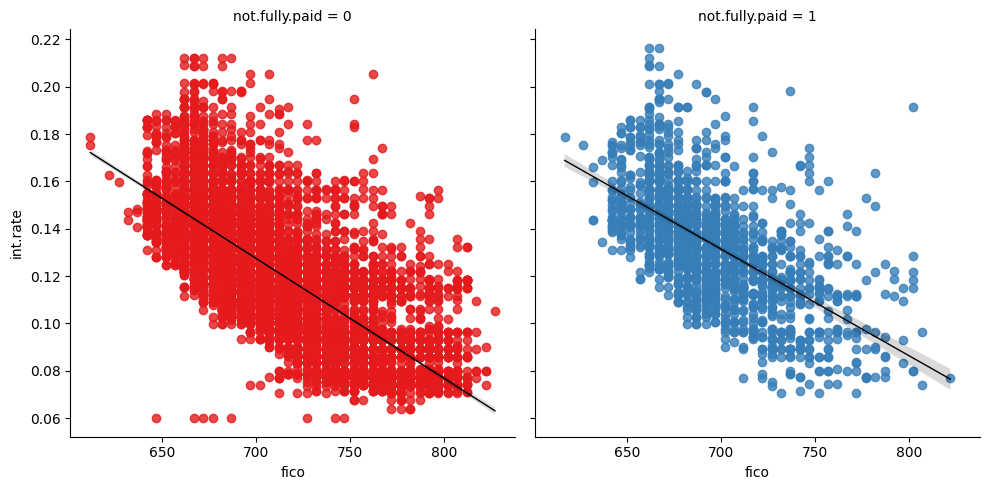

In [20]:
# plot linear correlation between fico and interest rate separated by target variable
fig = plt.figure()
sns.lmplot(data=df,x='fico',y='int.rate',col='not.fully.paid',hue='not.fully.paid',palette='Set1',
          line_kws={'color':'black','lw':1})
plt.show()

We can see that `int.rate` and `fico` have an inverse relationship: lower `fico` is correlated with higher `int.rate`. We will see the Pearson correlation coefficient in a later section when we perform a correlation analysis. 

We can also investigate some key features separated by the target variable, including `fico` and `purpose`. 

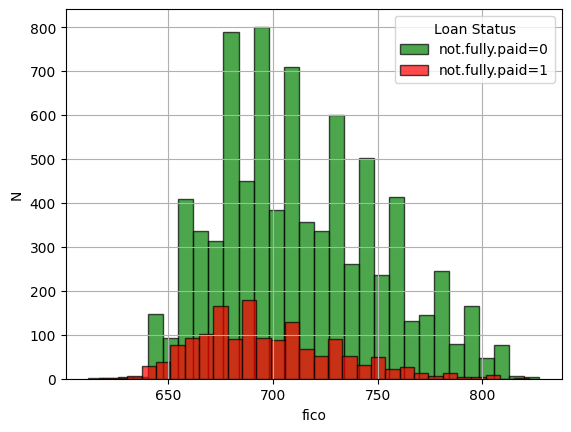

In [23]:
fig = plt.figure()
# fico distribution where not.fully.paid=0
df[df['not.fully.paid']==0]['fico'].hist(bins=30,color='green',edgecolor='black',alpha=0.7,label='not.fully.paid=0')
# fico distribution where not.fully.paid=1
df[df['not.fully.paid']==1]['fico'].hist(bins=30,color='red',edgecolor='black',alpha=0.7,label='not.fully.paid=1')
plt.xlabel('fico')
plt.ylabel('N')
plt.legend(title='Loan Status')
plt.show()

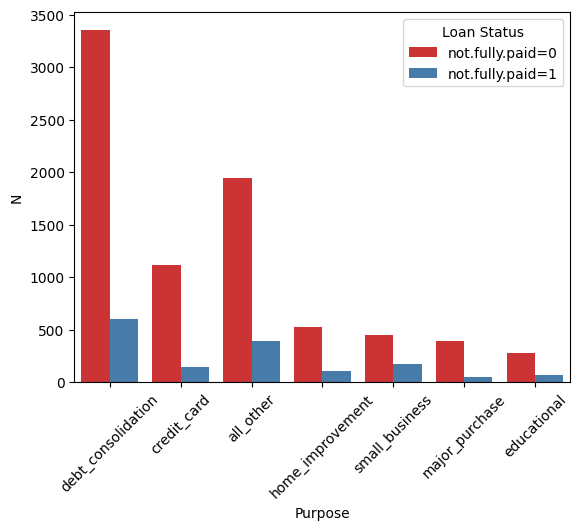

In [24]:
fig = plt.figure()
# purpose distribution separated by target variable
sns.countplot(data=df,x='purpose',hue='not.fully.paid',palette='Set1')
plt.xticks(rotation=45)
plt.xlabel('Purpose')
plt.ylabel('N')
plt.legend(title="Loan Status",labels=["not.fully.paid=0","not.fully.paid=1"])
plt.show()

These distirbutions reveal that there is no drastic difference between those who have fully paid off their loans vs. those who haven't. 

### Step 2.5: Check for Missing Values, Invalid Entries, or Duplicates
Next we look for missing values, invalid entries, and duplicate samples. We saw previously that some columns had less than the maximum number of data samples, likely indicative of missing data. Let's start by looking for `null` entries using `panda`'s `df.isnull()` function.

In [27]:
df.isnull().sum()

credit.policy         0
purpose               0
int.rate              0
installment           0
log.annual.inc        4
dti                   0
fico                  0
days.with.cr.line    29
revol.bal             0
revol.util           62
inq.last.6mths       29
delinq.2yrs          29
pub.rec              29
not.fully.paid        0
dtype: int64

This reveals that multiple columns (`log.annual.inc`, `days.with.cr.line`, `revol.util`, `inq.last.6mths`, `delinq.2yrs`, and `pub.rec`) have missing entries. Let's see what fraction of the entire dataset these missing entries represent. 

In [29]:
# iterate through each column
for col in df.columns:
    # calculate number of null entries
    null_sum = df[col].isnull().sum()
    # check if there is a null entry
    if null_sum>0:
        # calculate fraction of nulls
        null_frac = null_sum/len(df[col])*100
        print(f"{col}: {null_sum} null entries ({null_frac:.2f}%)")

log.annual.inc: 4 null entries (0.04%)
days.with.cr.line: 29 null entries (0.30%)
revol.util: 62 null entries (0.65%)
inq.last.6mths: 29 null entries (0.30%)
delinq.2yrs: 29 null entries (0.30%)
pub.rec: 29 null entries (0.30%)


While these columns have null entries, they only account for less than 1% of the total number of data samples. This is a relatively large dataset with approximately 9.6k data samples, so we will just drop all data samples what have null entries using `panda`s `dropna()` function. If the dataset were significantly smaller and we wanted to preserve all of the data, imputation with the median value would be a reasonable approach. 

In [31]:
df.dropna(inplace=True)

Let's verify that the nulls no longer exist.

In [33]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

When searching for missing or invalid entries, I typically like to search the object columns for placeholders such as `?` and `...` that might represent missing data. We only need to do this for the one object column (`purpose`).

In [35]:
# define placeholder entries to search for
placeholders = ['?', '.', 'na', 'n/a', 'none']

for col in df.select_dtypes(include='object'):
    mask = df[col].isin(placeholders)
    if mask.any():
        print(f"{col}:\n {df[mask]}\n\n")
    else:
        print(f"{col}: No placeholder entries.")

purpose: No placeholder entries.


This indicates that the `purpose` column likely doesn't have any missing or invalid entries. Since there is only one object column, we can be even more thorough and summarize the unique entries in this column to look for any unusual entries. With much larger datasets or those with a large number of object columns, this can be a time consuming and computationally expensive task.

In [37]:
df['purpose'].value_counts()

purpose
debt_consolidation    3949
all_other             2290
credit_card           1259
home_improvement       628
small_business         618
major_purchase         432
educational            340
Name: count, dtype: int64

We can see that there are only 7 unique entries in the `purpose` column, none of which are placeholders of missing or invalid entries. 

Next, let's search for duplicate samples using `panda`'s `df.duplicated()` function.

In [40]:
df.duplicated().sum()

0

This reveals that there are no duplicate samples.

## Step 3: Feature Engineering
Common feature engineering steps include scaling the numeric features to a common scale (e.g., a mean of zero and standard deviation of one) and encoding the categorical features. However, decision tree and random forest models do not rely on distance metrics, so it is not necessary to scale the continuous features (unless the performance of the model is to be compared to a model that is sensitive to feature scaling). There is one object column in the dataset, `purpose`, so we will encode this feature. 

### Step 3.1 One-Hot Encoding
We'll start by one-hot encoding the nominal features, which are categorical features that don't have a natural order. For this we'll use `panda`'s `pd.get_dummies()` function, which converts the categorical features into binary features. Using the `drop_first=True` argument drops the redundant binary column, which helps to reduce multicolinearity. I'll generate the dummy variables separately so we can easily convert them from boolean type (True or False) to integer values (1 or 0).

In [44]:
# define nominal features for one-hot encoding
nominal_features = ['purpose']

# create dummy variables for nominal feature and convert to integer data type
df_dummies = pd.get_dummies(df[nominal_features],drop_first=True).astype(int)
encoded_nominal_features = df_dummies.columns.to_list()

# drop original nominal features from dataframe as they're now redundant
df = df.drop(columns=nominal_features)

# concatenate original dataframe with that containing the dummy variables
df = pd.concat([df, df_dummies], axis=1)

In [45]:
# review updated dataframe
df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0.0,0.0,0.0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0.0,0.0,0.0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1.0,0.0,0.0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1.0,0.0,0.0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0.0,1.0,0.0,0,1,0,0,0,0,0


## Step 4: Correlation Analysis
Decision tree and random forest models are not particularly sensitive to multicollinearity in the way that linear models like linear regression and logistic regression are because the ir split points are not based on linear coefficients. However, it is still worth exploring whether there are redundant features as this can reduce feature importance and interpretability. For this, we will explore the correlations between input features by building a correlation matrix using `panda`'s `.corr()` function and identifying cases where the Pearson correlation coefficient indicates a strong correlation ($|r|>0.8$).

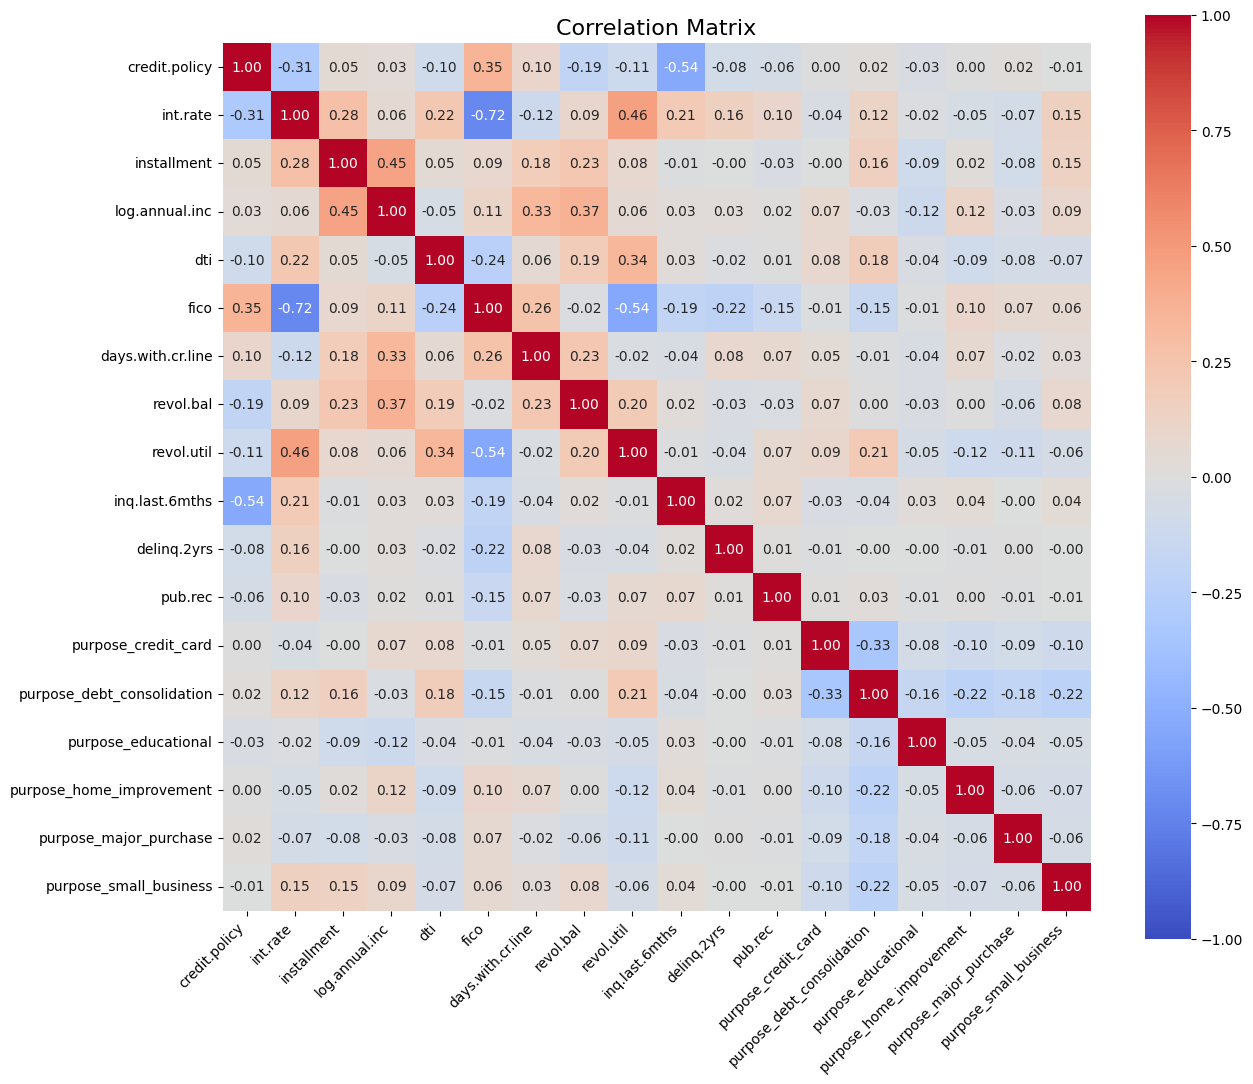

Pairs of correlated features: []


In [47]:
# compute correlation matrix
corr_matrix = df.drop(columns=['not.fully.paid']).corr()

# plot correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",annot_kws={"size": 10},cmap="coolwarm",vmin=-1,vmax=1,square=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

corr_feature_pairs = []
# iterate through indices of upper-right triangle
# of correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i+1,len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        # correlated pairs if |r|>0.8
        if abs(r) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_feature_pairs.append((col1,col2))

print("Pairs of correlated features:", corr_feature_pairs)

The correlation matrix reveals that no feature pairs meet our threshold to be considered strongly correlated, so we will retain all of the features.

## Step 5. Train Test Split
I'll follow the standard process of separating the input features (`X`) from the target variable (`y`) and splitting the data into training (`_train`) and testing (`_test`) sets using `scikit-learn`'s `train_test_split()` function. Splitting the data into training and testing sets allows us to evaluate the model performance using an independent dataset that the model hasn't seen during its training phase. This is an essential step for determining how well an ML model generalizes to unseen data.

In [86]:
# define features
X = df.drop(columns=['not.fully.paid'])

# define target variable
y = df['not.fully.paid']

While creating the training and testing sets, we will use `train_test_split`'s `stratify` argument to ensure that the relative proportions of each class (negative and positive) are the same in all subsets as the original dataset. 

In [89]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

## Step 6. Decision Tree Modelling
Our data have been cleaned and pre-processed so we'll start by training a decision tree model. 

### Step 6.1. Train the Decision Tree Model
Let's train the decision tree model using `scikit-learn`'s `DecisionTreeClassifier()` function. Since we know that there is a signifncant class imbalance, we will use the `class_weight='balanced'` argument to adjust the weights of each class to ensure that they contribute equally to the training phase. 

In [93]:
# train the model
dtree = DecisionTreeClassifier(class_weight='balanced',random_state=42)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

### Step 6.2. Make Predictions on the Test Set
With the decision tree model trained, let's make predictions and take a look at the distribution of the predicted class labels.

In [96]:
# make predictions
y_predict_dtree = dtree.predict(X_test)

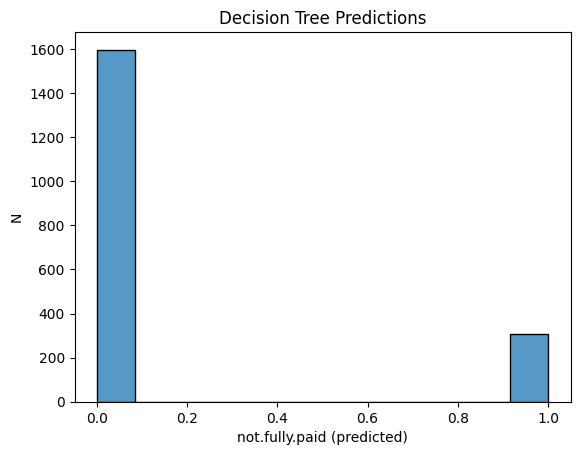

In [98]:
# plot the histogram of predicted class labels
sns.histplot(y_predict_dtree)
plt.xlabel('not.fully.paid (predicted)')
plt.ylabel('N')
plt.title('Decision Tree Predictions')
plt.show()

We know that there is a class imbalance in the target variable, which means that classification models can be biased towards the majority class label (`not.fully.paid=0`). We will address this, but first let's test the model performance so we can see the impact of addressing the class imbalance.

### Step 6.3. Test Model Performance

We will now test the model performance to get a better understanding of how well the decision tree model performs on unseen data.

#### Step 6.3.1. Confusion Matrix

The confusion matrix is a diagnostic tool used to evaluate the performance of a classification model by summarizing how the predicted class labels compare to the actual class labels. For binary classification, the confusion matrix is a 2x2 matrix where the elements along the diagonal represent the true negative (TN) and true positive (TP) class labels (i.e., correct labels), while the off-diagonal elements represent the false negative (FN) and false positive (FP) class labels (i.e., incorrect labels). This simple structure demonstrates whether the model is able to properly separate positive and negative class labels, and whether there is any confusion between them.

It is worth noting that different sources use different conventions for the confusion matrix; `scikit-learn` uses the following convention: "...the count of true negatives is [0,0], false negatives is [1,0], true positives is [1,1] and false positives is [0,1]." Knowing this allows us to calculate two additional metrics that aren't included in the classification report (next step): the false positive rate (FPR) and false negative rate (FNR).

[[1367  233]
 [ 230   74]]


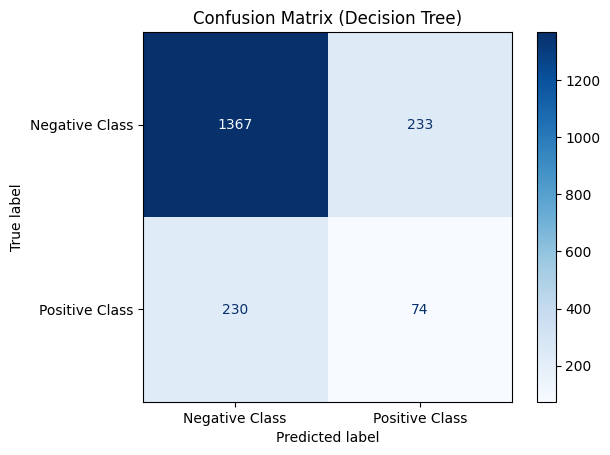

The FPR is 14.6% and the FNR is 75.7%.


In [343]:
# compute confusion matrix
cm_dtree = confusion_matrix(y_test,y_predict_dtree)
print(cm_dtree)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dtree, display_labels=['Negative Class', 'Positive Class'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Decision Tree)')
plt.show()

# define entries of confusion matrix
tn_dtree = cm_dtree[0,0]
fn_dtree = cm_dtree[1,0]
tp_dtree = cm_dtree[1,1]
fp_dtree = cm_dtree [0,1]

# calculate the FPR and FNR
fpr_dtree = fp_dtree/(fp_dtree+tn_dtree)
fnr_dtree = fn_dtree/(fn_dtree+tp_dtree)
print(f"The FPR is {fpr_dtree*100:.1f}% and the FNR is {fnr_dtree*100:.1f}%.")

The confusion matrix is what we would expect with the given class imbalance: a somewhat reasonable FPR (13.2%) but a very high FNR (77.0%), meaning that the decision tree model fails to correctly identify more than three quarters of the actual positive class.

#### Step 6.3.2. Classification Report
The classification report is another common diagnostic tool used to evaluate the performance of a classification model, which summarizes four key metrics: precision, recall, f1-score, and support.

Precision quantifies how well you can trust a positive prediction, measured as the proportion of positive predictions that were correct:

$$
\begin{aligned}
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}.
\end{aligned}
$$

The recall is complementary to precision, which quantifies the coverage of true positives measured as the proportion of true positives that were identified:

$$
\begin{aligned}
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}.
\end{aligned}
$$

The F1-score is the harmonic mean of precision and recall, which offers a more balanced metric and can be particularly useful when there is a class imbalance:

$$
\begin{aligned}
\text{F1-score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}.
\end{aligned}
$$

Lastly, support is the total number of occurrences in each class label and can help to provide context for the above key metrics, particularly in the case of a class imbalance.

In [106]:
# compute classification report
classification_report_dtree = classification_report(y_test,y_predict_dtree)
print(classification_report_dtree)

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1600
           1       0.24      0.24      0.24       304

    accuracy                           0.76      1904
   macro avg       0.55      0.55      0.55      1904
weighted avg       0.76      0.76      0.76      1904



The issue of class imbalance is further demonstrated by the classification report: the precision, recall, and f1-score are all quite strong for the negative (majority) class but are weak for the positive (minority) class. For these reasons, we will re-train the decision tree model to optimize the performance metrics on the negative (minority) class.

#### Step 6.3.3. ROC-AUC Score
The ROC (Receiver Operating Characteristic) curve is a diagnostic tool that visualizes the trade-off between the True Positive Rate (TPR, also known as sensitivity or recall) and the False Positive Rate (FPR) at various classification thresholds. A perfect classifier would have a curve that hugs the top-left corner of the plot, while a model that performs no better than random chance would follow the diagonal line. The AUC (Area Under the Curve) quantifies the overall ability of the model to distinguish between classes. In the case of a perfect classifier, the AUC would be 1.0 since the ROC curve hugs the top-left cornere of the plot. In contrast, a classifier that is unable to discriminate between classes would have an AUC closer to 0.5 since the ROC curve would follow the diagonal.

In [108]:
# get predicted probabilities for positive class
y_proba_dtree = dtree.predict_proba(X_test)[:, 1]

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_proba_dtree)

# compute AUC score
auc_score_dtree = roc_auc_score(y_test,y_proba_dtree)

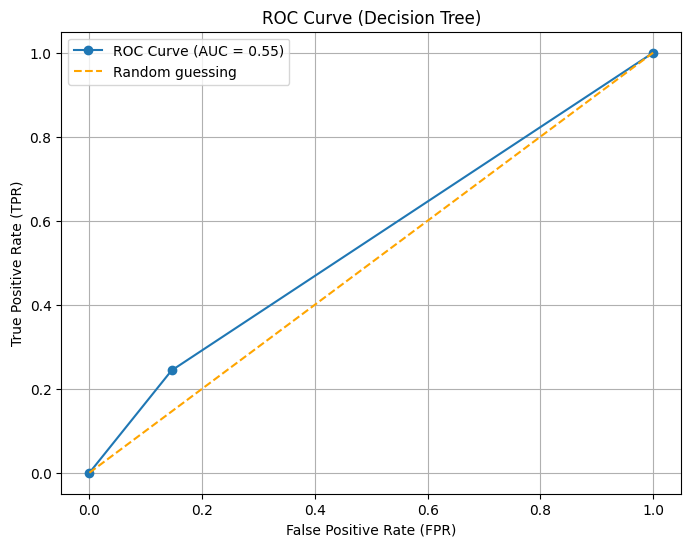

In [110]:
# plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,'-o',color='tab:blue',label=f"ROC Curve (AUC = {auc_score_dtree:.2f})") # ROC curve with AUC score
plt.plot([0,1],[0,1],color="tab:orange",linestyle="dashed",label="Random guessing") # 1:1 line for random guessing
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Decision Tree)")
plt.legend()
plt.grid(True)
plt.show()

The ROC-AUC makes it clear that the decision tree model is performing only slightly better than random guessing. With such significant class imbalances, the accuracy of a model can be misleading because a model could guess the majority class most of the time and still achieve a high accuracy without having the necessary ability to distinguish between the two classes. In such cases, the ROC-AUC metric more accurately demonstrates the model's ability to distinguish between true positive and negative classes regardless of the class distribution. 

#### Step 6.3.4. Precision-Recall AUC Score
The precision-recall (PR) curve is a diagnostic tool similar to the ROC curve that is particularly well-suited for imbalanced classification tasks. It visualizes the trade-off between precision (the proportion of correct positive predictions) and recall (the proportion of correctly-identified actual positives) across different classification thresholds. Unlike the ROC curve, which incorporates the FPR, the PR curve focuses solely on the performance of the the positive class. This makes it especially informative when the minority class is of primary interest, such as the case here, as it can provide a more realistic picture of model performance.

The Average Precision (AP) score, also referred to as the area under the precision-recall curve (PR-AUC), summarizes the trade-off between precision and recall into a single value. A high PR-AUC indicates that the model is able to maintain high precision without sacrificing recall across thresholds. In contrast, a low PR-AUC suggests that the model either misses many true positives (low recall) or makes many false positive predictions (low precision), or both.

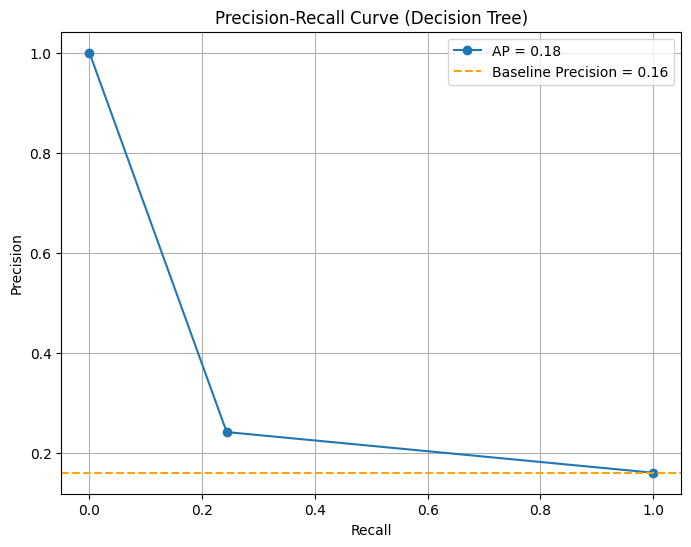

In [114]:
# compute precision-recall curve
precision,recall,thresholds = precision_recall_curve(y_test,y_proba_dtree)

# compute average precision
avg_precision = average_precision_score(y_test,y_proba_dtree)

# plot precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall,precision,"-o",color="tab:blue",label=f'AP = {avg_precision:.2f}')
plt.axhline(0.16,linestyle="dashed",color="tab:orange",label="Baseline Precision = 0.16")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Decision Tree)")
plt.legend()
plt.grid(True)
plt.show()

The PR curve rapidly declines in precision as recall increases and has a low average precision (AP) score of 0.18, demonstrating that the model fails to maintain a high precision while identifying the rare positive cases (a common challenge with imbalanced datasets). This highlights the need for resampling techniques, such as SMOTE, which we will try next. 

### Step 6.4. Resample with SMOTE

In [135]:
# initialize SMOTE
smote = SMOTE(random_state=42)

# resample training data
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

# compare class numbers before and after SMOTE resampling
print("Target label value counts before SMOTE:", y_train.value_counts(), "\n")
print("Target lable value counts after SMOTE:", y_train_smote.value_counts())

Target label value counts before SMOTE: not.fully.paid
0    6395
1    1217
Name: count, dtype: int64 

Target lable value counts after SMOTE: not.fully.paid
0    6395
1    6395
Name: count, dtype: int64


### Step 6.5. Re-Train the Decision Tree Model
Let's now re-train the decision tree model using `scikit-learn`'s `DecisionTreeClassifier()` function using the resampled training data. Once againe, we will use the `class_weight='balanced'` argument to adjust the weights of each class to ensure that they contribute equally to the training phase. 

In [124]:
# re-train the model
dtree_smote = DecisionTreeClassifier(class_weight='balanced',random_state=42)
dtree_smote.fit(X_train_smote,y_train_smote)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

### Step 6.6. Make Predictions on the Resampled Test Set
With the decision tree model re-trained on the resampled training data, let's make predictions and take a look at the distribution of the predicted class labels.

In [137]:
# make predictions
y_predict_dtree_smote = dtree_smote.predict(X_test)

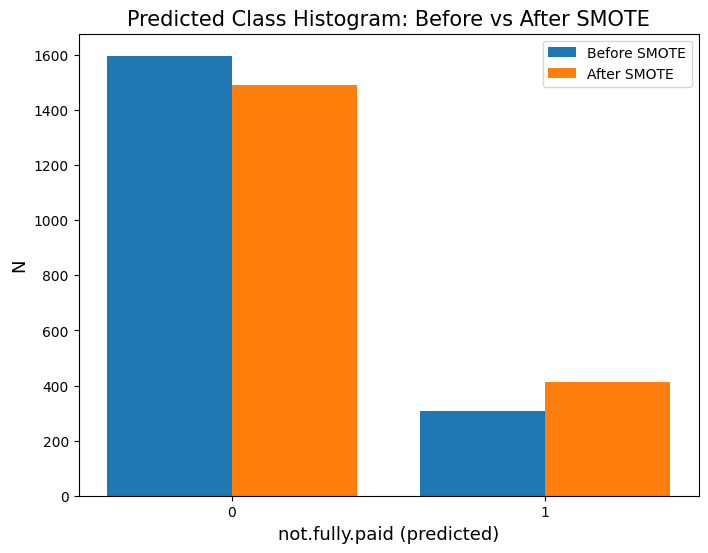

In [339]:
# create list of predictions for plotting
y_preds = [y_predict_dtree, y_predict_dtree_smote]

# create histogram
fig = plt.figure(figsize=(8,6))
plt.hist(y_preds,bins=[-0.5, 0.5, 1.5],color=['tab:blue','tab:orange'],label=['Before SMOTE','After SMOTE'])
plt.xticks([0, 1])
plt.xlabel('not.fully.paid (predicted)',fontsize=13)
plt.ylabel('N',fontsize=13)
plt.title('Predicted Class Histogram: Before vs After SMOTE',fontsize=15)
plt.legend()
plt.savefig('./figures/dtree_labels_before_after_smote.png',bbox_inches='tight')
plt.show()

We can see that our re-trained model is now predicting slightly more positive class labels at the expense of slightly less negative class labels, as to be expected. 

### Step 6.7. Test Model Performance

We will now test the model performance of our re-trained model to see if the performance has improve with SMOTE resampling.

#### Step 6.7.1. Confusion Matrix

[[1284  316]
 [ 207   97]]


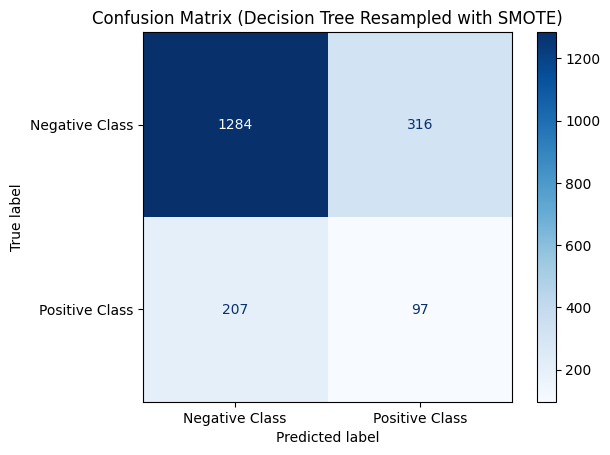

The FPR is 19.8% (from 14.6%) and the FNR is 68.1% (from 75.7%).


In [345]:
# compute confusion matrix
cm_dtree_smote = confusion_matrix(y_test,y_predict_dtree_smote)
print(cm_dtree_smote)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dtree_smote, display_labels=['Negative Class', 'Positive Class'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Decision Tree Resampled with SMOTE)')
plt.show()

# define entries of confusion matrix
tn_dtree_smote = cm_dtree_smote[0,0]
fn_dtree_smote = cm_dtree_smote[1,0]
tp_dtree_smote = cm_dtree_smote[1,1]
fp_dtree_smote = cm_dtree_smote[0,1]

# calculate the FPR and FNR
fpr_dtree_smote = fp_dtree_smote/(fp_dtree_smote+tn_dtree_smote)
fnr_dtree_smote = fn_dtree_smote/(fn_dtree_smote+tp_dtree_smote)
print(f"The FPR is {fpr_dtree_smote*100:.1f}% (from {fpr_dtree*100:.1f}%) and the FNR is {fnr_dtree_smote*100:.1f}% (from {fnr_dtree*100:.1f}%).")

Resampling with SMOTE increased the FPR by 5.2% and decreased the FNR by 7.6%. This is to be expected because re-sampling with SMOTE trained the data to identify more positive class labels, which comes at the expense of less negative class labels. This is a step in the right direction in cases such as these where we want to prioritize capturing as many true positives as much as possible. 

#### Step 6.7.2. Classification Report

In [187]:
# compute classification report
classification_report_dtree_smote = classification_report(y_test,y_predict_dtree_smote)
print(classification_report_dtree_smote)

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1600
           1       0.23      0.32      0.27       304

    accuracy                           0.73      1904
   macro avg       0.55      0.56      0.55      1904
weighted avg       0.76      0.73      0.74      1904



The classification report demonstrates that the positive class recall increased by 8%, while the positive class precision dropped by 1%. This means that our re-trained model has improved its ability to identify positive class labels, just like we wanted. 

#### Step 6.7.3. ROC-AUC Score

In [197]:
# get predicted probabilities for positive class
y_proba_dtree_smote = dtree_smote.predict_proba(X_test)[:, 1]

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_proba_dtree_smote)

# compute AUC score
auc_score_dtree_smote = roc_auc_score(y_test,y_proba_dtree_smote)

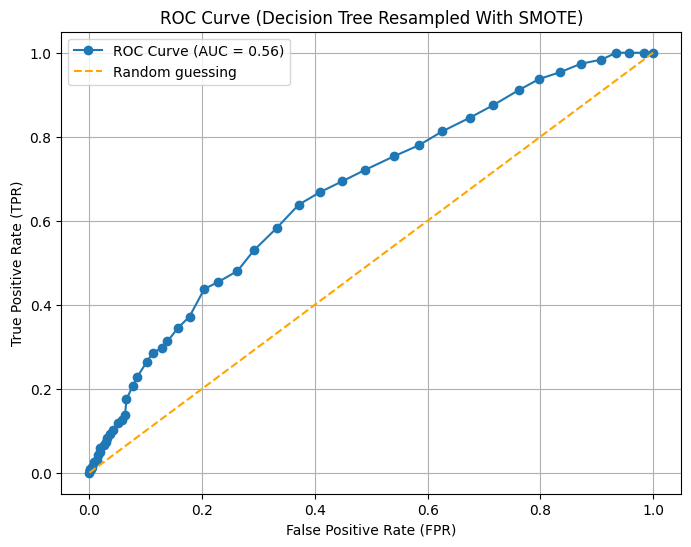

In [347]:
# plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,'-o',label=f"ROC Curve (AUC = {auc_score_dtree_smote:.2f})") # ROC curve with AUC score
plt.plot([0,1],[0,1],color="orange",linestyle="dashed",label="Random guessing") # 1:1 line for random guessing
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Decision Tree Resampled With SMOTE)")
plt.legend()
plt.grid(True)
plt.show()

While the re-trained model has a slightly better recall, its ROC-AUC has only marginally improved by 0.01. Since the ROC-AUC quantifies how well a model can identify the positive class over negative class labels, this suggests that the re-trained model still does only slightly better than random guessing.

#### Step 6.7.4. Precision-Recall AUC Score

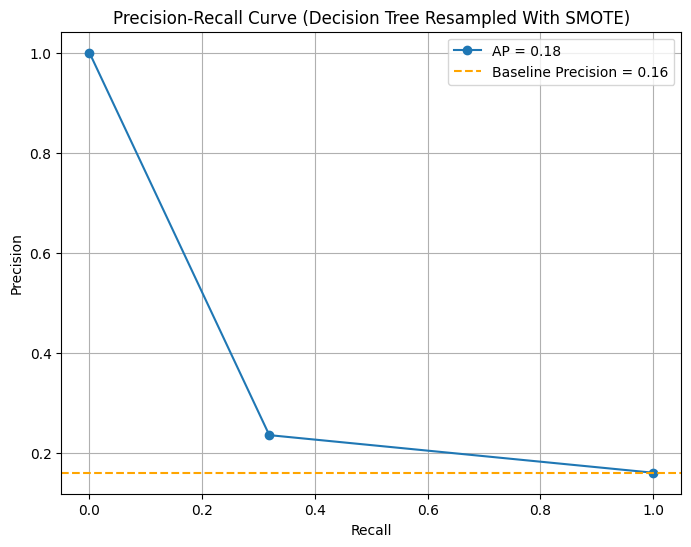

In [349]:
# compute precision-recall pairs
precision,recall,thresholds = precision_recall_curve(y_test,y_proba_dtree_smote)

# compute average precision score (AUC of PR curve)
avg_precision_dtree = average_precision_score(y_test,y_proba_dtree_smote)

# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall,precision,"-o",color='tab:blue',label=f'AP = {avg_precision_dtree:.2f}')
plt.axhline(0.16,linestyle="dashed",color="orange",label="Baseline Precision = 0.16")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Decision Tree Resampled With SMOTE)")
plt.legend()
plt.grid(True)
plt.show()

Similar to the ROC-AUC, the PR-AUC indicates that the model is barely performing better than random guessing when it comes to identifying the positive class label. As SMOTE alone did not achieve a high-performing model, we will try hyperparamater tuning before we move on to a more complex model. 

### Step 6.8. Hyperparameter Tuning
We will now fine-tune the `max_depth` and `min_leaf` parameters for the re-trained decision tree model using stratified k-fold cross validation. To avoid data leakage, we will resample the training data using SMOTE within each $k$ fold rather than pass the previously SMOTE-resampled data. For this we will use `imblearn.pipeline`'s `Pipeline` function to ensure that SMOTE is only used on the training data within each fold. Rather than manually iterating through our parameter grid, we can use `scikit-learn`'s `GridSearchCV` function to automate this hyperparameter search. 

In [230]:
# set up stratified cross validation on training dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# define parameter grid
param_grid = {
    'model__max_depth'        : [4, 6, 8, 10],
    'model__min_samples_leaf' : [20, 50, 100, 200],
    'model__class_weight'     : ['balanced']
    }

# define scoring for cross valication
scoring = {'recall':'recall',
           'roc_auc':'roc_auc',
           'balanced_accuracy':'balanced_accuracy'
          }

# build pipeline
pipe = Pipeline(steps=[('smote',SMOTE(random_state=42)),('model',DecisionTreeClassifier(class_weight='balanced',random_state=42))])

# build grid search
grid = GridSearchCV(estimator=pipe,param_grid=param_grid,scoring=scoring,refit='recall',cv=cv,n_jobs=-1)

# run grid search on training dataset
grid.fit(X_train,y_train)

# transform results to a dataframe
grid_results = pd.DataFrame(grid.cv_results_)

# filter columns and sort by (average) recall, roc-auc, and balanced accuracy
grid_results = grid_results[['param_model__max_depth','param_model__min_samples_leaf','mean_test_recall','std_test_recall',
                             'mean_test_roc_auc','mean_test_balanced_accuracy']].sort_values(
                              by=['mean_test_recall','mean_test_roc_auc','mean_test_balanced_accuracy'],
                              ascending=[False, False, False]).reset_index(drop=True)

# print grid results
print(f"grid results:\n{grid_results}")

# print best-fit model parameters
print(f"best-fit model parameters (recall={grid.best_score_:.2f}): {grid.best_params_}")

grid results:
   param_model__max_depth param_model__min_samples_leaf  mean_test_recall  std_test_recall  mean_test_roc_auc  mean_test_balanced_accuracy
0                       6                           200          0.349180         0.071526           0.635528                     0.574747
1                       6                            50          0.312157         0.086521           0.625958                     0.565930
2                       6                            20          0.306406         0.075007           0.621852                     0.564227
3                       6                           100          0.300668         0.083888           0.629918                     0.561827
4                      10                           200          0.277704         0.030647           0.631047                     0.569423
5                       8                           200          0.277704         0.030647           0.629886                     0.569423
6            

Hyperparameter tuning using $k$-fold cross-validation yields an 'optimal' decision tree model with an average recall of only 35% (a 3% increase) and an ROC-AUC of 0.64 (a 0.08 increase). These results demonstrate that hyperparameter tuning alone is unsufficient to train a decision tree model that can meaningfully differentiate between the positive and negative class with such a significant class imbalance. In light of this, we will try a more complex random forest model to see if we can improve recall performance.

## Step 7. Random Forest Modelling
To improve on the model's ability to differentiate between the two classes in the presence of a significant class imbalance, we will train a random forest model to search for an improvement in recall. The testing and training data have already been split, so we can go straight to training the model.

### Step 7.1. Train the Random Forest Model
Let's now train the random forest model using `scikit-learn`'s `RandomForestClassifier()` function. Since we know that there is a signifncant class imbalance, we will use the `class_weight='balanced'` argument to adjust the weights of each class to ensure that they contribute equally to the training phase, just like when we trained the decision tree model. By default, the number of trees used in the model is 100; for transparency, we will set this explicitly using `n_estimators=100`. Similar to before, we will also set `n_jobs=-1` to use all CPU cores.

In [234]:
rf = RandomForestClassifier(class_weight='balanced',n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

### Step 7.2. Make Predictions on the Test Set
With the random forest model trained, let's make predictions using the model.

In [240]:
y_predict_rf = rf.predict(X_test)

### Step 7.3. Test Model Performance

We will now test the model performance to get see how well the random forest model performs on unseen data. For completeness, we will check the same performance metrics as before before we proceed with optimizing the model.

#### Step 7.3.1. Confusion Matrix

Let's start with the confusion matrix. 

[[1599    1]
 [ 302    2]]


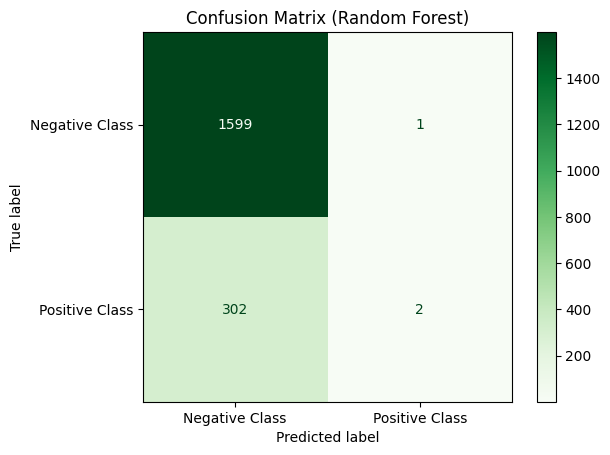

The FPR is 0.1% and the FNR is 99.3%.


In [355]:
# compute confusion matrix
cm_rf = confusion_matrix(y_test,y_predict_rf)
print(cm_rf)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Negative Class', 'Positive Class'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix (Random Forest)')
plt.show()

# define entries of confusion matrix
TN_rf = cm_rf[0,0]
FN_rf = cm_rf[1,0]
TP_rf = cm_rf[1,1]
FP_rf = cm_rf[0,1]

# calculate the FPR and FNR
FPR_rf = FP_rf/(FP_rf+TN_rf)
FNR_rf = FN_rf/(FN_rf+TP_rf)
print(f"The FPR is {FPR_rf*100:.1f}% and the FNR is {FNR_rf*100:.1f}%.")

Once again, we are seeing the classic signs of a significant class imbalance: the random forest only has one false positive with a FPR of 0.1% but misclassifies 302 as negatives with a FNR of 99.3%. 

#### Step 7.3.2. Classification Report
Let's now check the classification report. 

In [247]:
# compute classification report
classification_report_rf = classification_report(y_test,y_predict_rf)
print(classification_report_rf)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1600
           1       0.67      0.01      0.01       304

    accuracy                           0.84      1904
   macro avg       0.75      0.50      0.46      1904
weighted avg       0.81      0.84      0.77      1904



While the model has a perfect recall of the negative (majority) class, it has a very poor recall of the positive (minority) class label. 

#### Step 7.3.3. ROC-AUC Score
Next, we have the ROC-AUC score.

In [249]:
# get predicted probabilities for positive class
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# compute ROC curve
fpr,tpr,thresholds = roc_curve(y_test,y_proba_rf)

# compute AUC score
auc_score_rf = roc_auc_score(y_test,y_proba_rf)

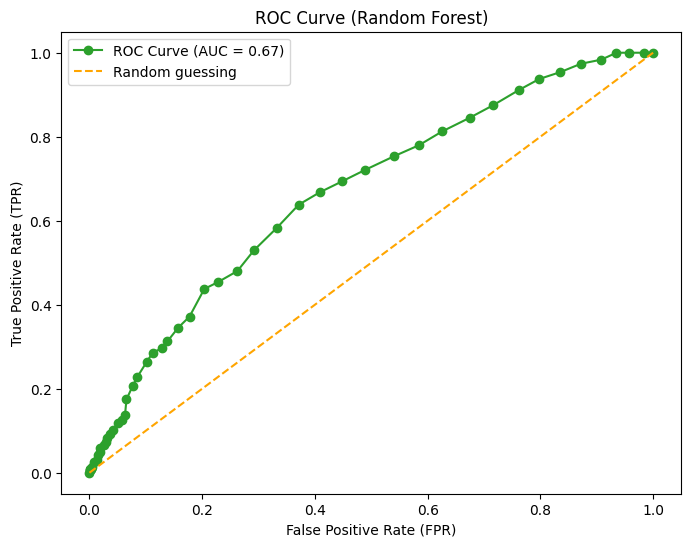

In [370]:
# plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,'-o',color='tab:green',label=f"ROC Curve (AUC = {auc_score_rf:.2f})") # ROC curve with AUC score
plt.plot([0,1],[0,1],color="orange",linestyle="dashed",label="Random guessing") # 1:1 line for random guessing
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Random Forest)")
plt.legend()
plt.show()

The ROC-AUC score reveals a modest improvement in the random forest model (AUC=0.67) compared to the decision tree model (AUC=0.55). However, there is still a lot of room for improvement. 

#### Step 7.3.4. Precision-Recall AUC Score
Lastly, we have the PR-AUC score.

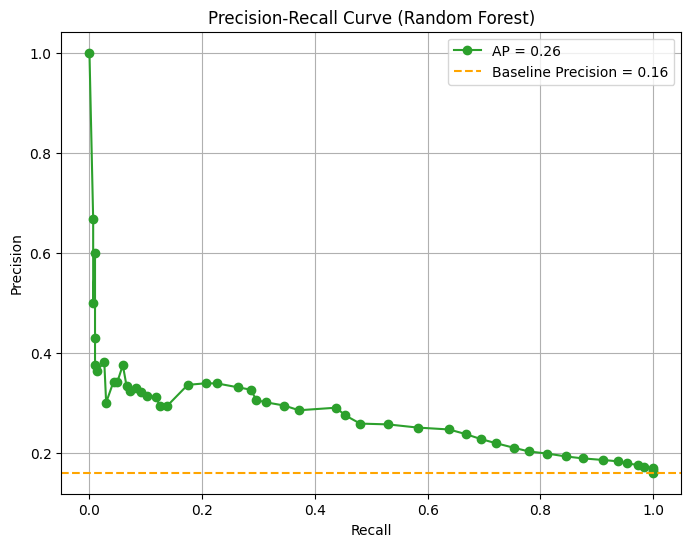

In [395]:
# compute precision-recall pairs
precision,recall,thresholds = precision_recall_curve(y_test,y_proba_rf)

# compute average precision score (AUC of PR curve)
avg_precision_rf = average_precision_score(y_test,y_proba_rf)

# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall,precision,"-o",color='tab:green',label=f'AP = {avg_precision_rf:.2f}')
plt.axhline(0.16,linestyle="dashed",color="orange",label="Baseline Precision = 0.16")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

The PR-AUC of the random forest model is 0.26, which is an improvement from that of the decision tree model (0.18). However, we can still see that the precision rapidly drops with recall, so we will use hyperparameter tuning to see if we can maintain precision as we prioritize a high recall.

## Step 8. Random Forest Modelling With Hyperparameter Tuning

With our preliminary random forest model trained, we will now tune several model parameters to optimize recall.

### Step 8.1. Random Search
We will now fine-tune the random forest model parameters to optimize recall. Since we will be fine-tuning a larger number of parameters compared to the decision tree model, we will use `RandomizedSearchCV()` instead of `GridSearchCV()` for faster tuning over a larger parameter space. Once again, we will use `n_jobs=-1` to use all CPU cores. We will randomly search 200 samples of the parameter search grid using `n_iter=200`, use 5 equal folds in our cross-validation using `cv=5`, and optimize recall using `scoring='recall'`. By default, this will assume that recall will be optimized for the `label=1` positive class label, which is correct in our case.

In [387]:
# define parameter grid
param_grid = {
    'n_estimators': [50, 100, 300, 500],
    'max_depth': [10, 20, 50, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [10, 20, 50, 100, 200],
    'max_features': ['sqrt', 'log2', None, 0.5],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample']
}

# build the model
rf = RandomForestClassifier(random_state=42)

# perform random search on parameter grid
search_rf = RandomizedSearchCV(rf,param_grid,n_iter=200,cv=3,scoring='recall',random_state=42,n_jobs=-1)
search_rf.fit(X_train,y_train)

# save best model
rf_tuned = search_rf.best_estimator_
y_predict_rf_tuned = rf_tuned.predict(X_test)

In [410]:
# transform results to a dataframe
search_rf_results = pd.DataFrame(search_rf.cv_results_)

# filter columsn and sort by (average) recall, roc-auc, and balanced accuracy
search_rf_results = search_rf_results[['param_n_estimators','param_min_samples_split','param_min_samples_leaf','param_max_features',
                             'param_max_depth','param_class_weight','param_bootstrap',
                             'mean_test_score','std_test_score','rank_test_score']].sort_values(
                              by=['mean_test_score','rank_test_score'],
                              ascending=[False, True]).reset_index(drop=True)

# print grid results
print(f"random search results (top 10):\n{search_rf_results[:10]}")

# print best-fit model parameters
print(f"best-fit model parameters (recall={search_rf.best_score_:.2f}): {search_rf.best_params_}")

random search results (top 10):
  param_n_estimators param_min_samples_split param_min_samples_leaf param_max_features param_max_depth  param_class_weight param_bootstrap  mean_test_score  std_test_score  rank_test_score
0                 50                       5                    200               log2              20            balanced            True         0.603933        0.024181                1
1                 50                       2                    200               None              20  balanced_subsample           False         0.601496        0.020321                2
2                100                      20                    200               None              50  balanced_subsample           False         0.601496        0.020321                2
3                100                       2                    200               sqrt            None            balanced            True         0.600655        0.027239                4
4                100   

Our best-fit random forest model has a recall of 60% with the above listed parameters. Let's review the change in class labels with the addition of hyperparameter tuning.

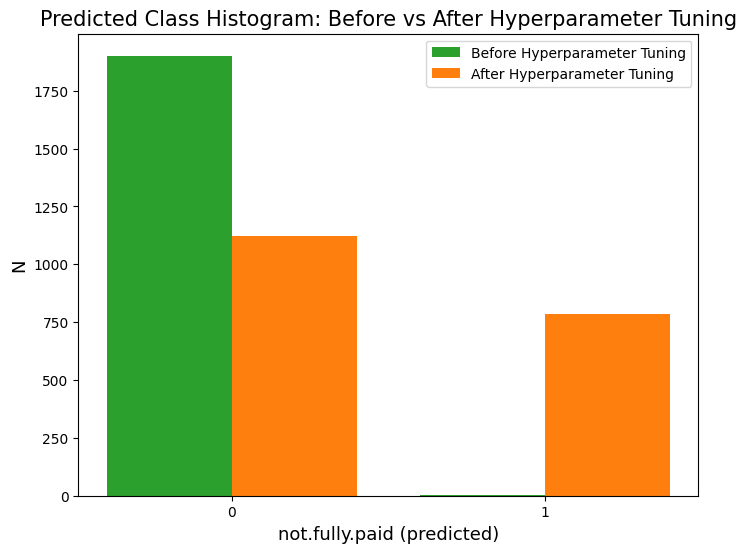

In [421]:
# create list of predictions for plotting
y_preds = [y_predict_rf, y_predict_rf_tuned]

# create histogram
fig = plt.figure(figsize=(8,6))
plt.hist(y_preds,bins=[-0.5, 0.5, 1.5],color=['tab:green','tab:orange'],label=['Before Hyperparameter Tuning','After Hyperparameter Tuning'])
plt.xticks([0, 1])
plt.xlabel('not.fully.paid (predicted)',fontsize=13)
plt.ylabel('N',fontsize=13)
plt.title('Predicted Class Histogram: Before vs After Hyperparameter Tuning',fontsize=15)
plt.legend()
plt.savefig('./figures/rf_labels_before_after_hyperparameter_tuning.png',bbox_inches='tight')
plt.show()

### Step 8.2. Test Model Performance

The best-fit random forest model has a recall of 60%, so let's review the performance metrics.

#### Step 8.2.1. Confusion Matrix

Let's start with the confusion matrix. 

[[998 602]
 [122 182]]


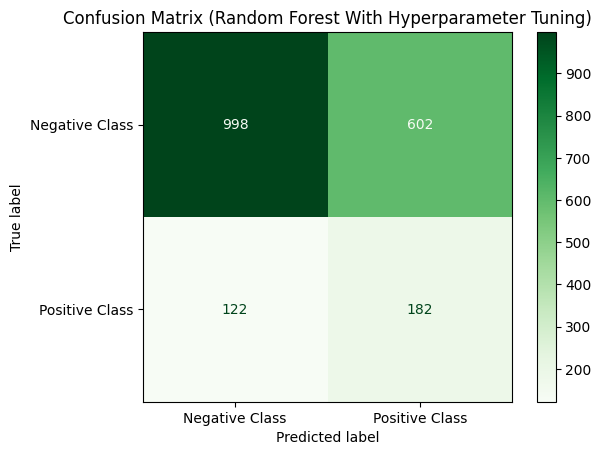

The FPR is 37.6% (from 0.1%) and the FNR is 40.1% (from 99.3%).


In [401]:
# compute confusion matrix
cm_rf_tuned = confusion_matrix(y_test,y_predict_rf_tuned)
print(cm_rf_tuned)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=['Negative Class', 'Positive Class'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix (Random Forest With Hyperparameter Tuning)')
plt.show()

# define entries of confusion matrix
TN_rf_tuned = cm_rf_tuned[0,0]
FN_rf_tuned = cm_rf_tuned[1,0]
TP_rf_tuned = cm_rf_tuned[1,1]
FP_rf_tuned = cm_rf_tuned[0,1]

# calculate the FPR and FNR
FPR_rf_tuned = FP_rf_tuned/(FP_rf_tuned+TN_rf_tuned)
FNR_rf_tuned = FN_rf_tuned/(FN_rf_tuned+TP_rf_tuned)
print(f"The FPR is {FPR_rf_tuned*100:.1f}% (from {FPR_rf*100:.1f}%) and the FNR is {FNR_rf_tuned*100:.1f}% (from {FNR_rf*100:.1f}%).")

#### Step 8.2.2. Classification Report
Let's now check the classification report. 

In [403]:
# compute classification report
classification_report_rf_tuned = classification_report(y_test,y_predict_rf_tuned)
print(classification_report_rf_tuned)

              precision    recall  f1-score   support

           0       0.89      0.62      0.73      1600
           1       0.23      0.60      0.33       304

    accuracy                           0.62      1904
   macro avg       0.56      0.61      0.53      1904
weighted avg       0.79      0.62      0.67      1904



#### Step 8.2.3. ROC-AUC Score
Next, we have the ROC-AUC score.

In [412]:
# get predicted probabilities for positive class
y_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# compute ROC curve
fpr,tpr,thresholds = roc_curve(y_test,y_proba_rf_tuned)

# compute AUC score
auc_score_rf_tuned = roc_auc_score(y_test,y_proba_rf_tuned)

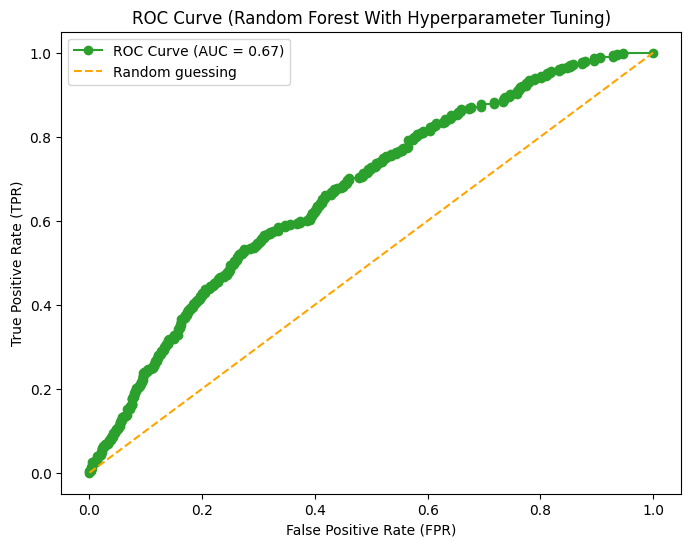

In [416]:
# plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,'-o',color='tab:green',label=f"ROC Curve (AUC = {auc_score_rf_tuned:.2f})") # ROC curve with AUC score
plt.plot([0,1],[0,1],color="orange",linestyle="dashed",label="Random guessing") # 1:1 line for random guessing
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Random Forest With Hyperparameter Tuning)")
plt.legend()
plt.show()

Interestingly, the optimal random forest model has the same ROC-AUC (0.67) as our preliminary decision tree model.

#### Step 8.2.4. Precision-Recall AUC Score
Lastly, we have the PR-AUC score.

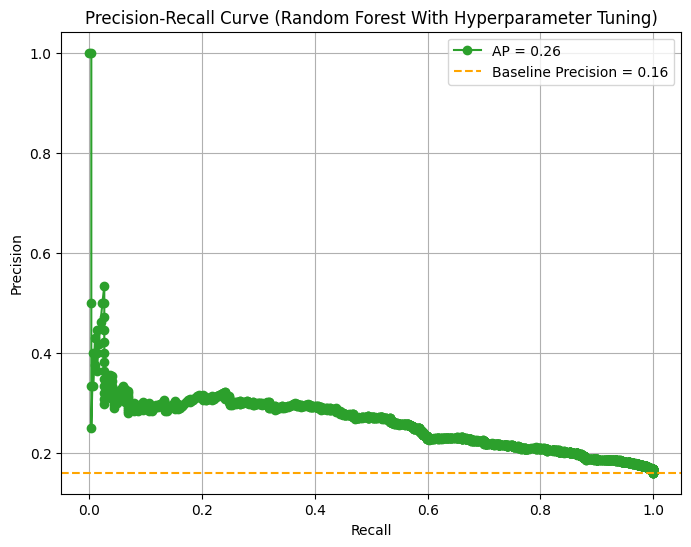

In [418]:
# compute precision-recall pairs
precision,recall,thresholds = precision_recall_curve(y_test,y_proba_rf_tuned)

# compute average precision score (AUC of PR curve)
avg_precision_rf_tuned = average_precision_score(y_test, y_proba_rf_tuned)

# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall,precision,"-o",color='tab:green',label=f'AP = {avg_precision_rf_tuned:.2f}')
plt.axhline(0.16,linestyle="dashed",color="orange",label="Baseline Precision = 0.16")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest With Hyperparameter Tuning)")
plt.legend()
plt.grid(True)
plt.show()

The AP (0.26) is also unchanged between the optimized and preliminary random forest models.

## Step 9. Random Forest Modelling With Hyperparameter Tuning And SMOTE
We will now fine-tune the random forest model parameters using stratified $k$-fold cross validation while resampling the training data with SMOTE to see if it improves recall.

### Step 9.1. Random Search

To avoid data leakage, we will resample the training data using SMOTE within each $k$ fold rather than pass the previously SMOTE-resampled data. For this we will use `imblearn.pipeline`'s `Pipeline` function to ensure that SMOTE is only used on the training data within each fold. We will again be searching through 200 random samples in the parameter space using `scikit-learn`'s `RandomSearchCV()` function. 

In [280]:
# define stratified CV
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# define pipeline
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

# define parameter grid
param_grid = {
    'model__n_estimators': [50, 100, 300, 500],
    'model__max_depth': [10, 20, 50, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [10, 20, 50, 100, 200],
    'model__max_features': ['sqrt', 'log2', None, 0.5],
    'model__bootstrap': [True, False],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

# define random search
search_rf_smote = RandomizedSearchCV(estimator=pipe,param_distributions=param_grid,n_iter=200,scoring='recall',cv=cv,n_jobs=-1,random_state=42,verbose=1)

# fit the models
search_rf_smote.fit(X_train, y_train)

# save best model
rf_tuned_smote = search_rf_smote.best_estimator_
y_predict_rf_tuned_smote = rf_tuned_smote.predict(X_test)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'model__bootstrap': [True, False],
                                        'model__class_weight': ['balanced',
                                                                'balanced_subsample'],
                                        'model__max_depth': [10, 20, 50, None],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None, 0.5],
                                        'model__min_samples_leaf': [10, 20, 50,
                                                                    100, 200],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     20],
                                        'model__n_estimators': [50, 100, 300,
                                                                500]},
                   random_state=42, scoring='recall', verbose=1)

In [284]:
# transform results to a dataframe
search_rf_smote_results = pd.DataFrame(search_rf_smote.cv_results_)

# filter columsn and sort by (average) recall, roc-auc, and balanced accuracy
search_rf_smote_results = search_rf_smote_results[['param_model__n_estimators','param_model__min_samples_split','param_model__min_samples_leaf',
                                                   'param_model__max_features','param_model__max_depth','param_model__class_weight',
                                                   'param_model__bootstrap','mean_test_score','std_test_score','rank_test_score']].sort_values(
                                                   by=['mean_test_score','rank_test_score'],
                                                   ascending=[False, True]).reset_index(drop=True)

# print grid results
print(f"random search results (top 10):\n{search_rf_smote_results[:10]}")

# print best-fit model parameters
print(f"best-fit model parameters (recall={search_rf_smote.best_score_:.2f}): {search_rf_smote.best_params_}")

random search results (top 10):
  param_model__n_estimators param_model__min_samples_split param_model__min_samples_leaf param_model__max_features param_model__max_depth param_model__class_weight param_model__bootstrap  \
0                        50                              5                           200                      log2                     20                  balanced                   True   
1                        50                             10                           200                      sqrt                   None        balanced_subsample                   True   
2                       500                             20                           200                      sqrt                     10                  balanced                   True   
3                       500                              5                           200                      log2                     20                  balanced                   True   
4                 

With SMOTE resampling, the best-fit random forest model actually has a lower recall (42%) than the one we found without SMOTE resampling (60%). For completeness, we will continue to review the performance metrics.

### Step 9.2. Test Model Performance

The best-fit random forest model with SMOTE resampling has a recall of 42%. Let's review the performance metrics.

#### Step 9.2.1. Confusion Matrix

Let's start with the confusion matrix. 

[[1263  337]
 [ 176  128]]


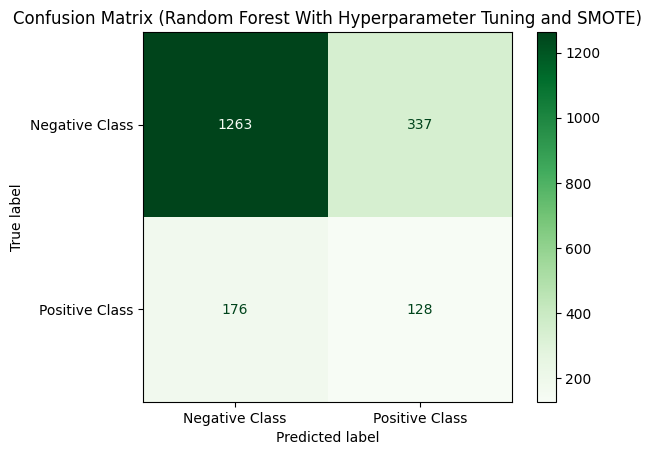

The FPR is 21.1% (from 37.6%) and the FNR is 57.9% (from 40.1%).


In [445]:
# compute confusion matrix
cm_rf_tuned_smote = confusion_matrix(y_test,y_predict_rf_tuned_smote)
print(cm_rf_tuned_smote)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned_smote,display_labels=['Negative Class', 'Positive Class'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix (Random Forest With Hyperparameter Tuning and SMOTE)')
plt.show()

# define entries of confusion matrix
TN_rf_tuned_smote = cm_rf_tuned_smote[0,0]
FN_rf_tuned_smote = cm_rf_tuned_smote[1,0]
TP_rf_tuned_smote = cm_rf_tuned_smote[1,1]
FP_rf_tuned_smote = cm_rf_tuned_smote[0,1]

# calculate the FPR and FNR
FPR_rf_tuned_smote = FP_rf_tuned_smote/(FP_rf_tuned_smote+TN_rf_tuned_smote)
FNR_rf_tuned_smote = FN_rf_tuned_smote/(FN_rf_tuned_smote+TP_rf_tuned_smote)
print(f"The FPR is {FPR_rf_tuned_smote*100:.1f}% (from {FPR_rf_tuned*100:.1f}%) and the FNR is {FNR_rf_tuned_smote*100:.1f}% (from {FNR_rf_tuned*100:.1f}%).")

#### Step 9.2.2. Classification Report
Let's now check the classification report. 

In [450]:
# compute classification report
classification_report_rf_tuned_smote = classification_report(y_test,y_predict_rf_tuned_smote)
print(classification_report_rf_tuned_smote)

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1600
           1       0.28      0.42      0.33       304

    accuracy                           0.73      1904
   macro avg       0.58      0.61      0.58      1904
weighted avg       0.78      0.73      0.75      1904



#### Step 9.2.3. ROC-AUC Score
Next, we have the ROC-AUC score.

In [454]:
# get predicted probabilities for positive class
y_proba_rf_tuned_smote = rf_tuned_smote.predict_proba(X_test)[:, 1]

# compute ROC curve
fpr,tpr,thresholds = roc_curve(y_test,y_proba_rf_tuned_smote)

# compute AUC score
auc_score_rf_tuned_smote = roc_auc_score(y_test,y_proba_rf_tuned_smote)

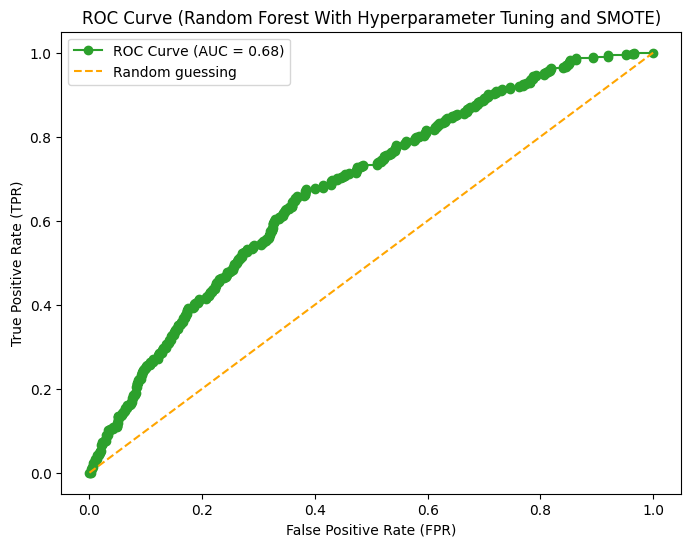

In [456]:
# plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,'-o',color='tab:green',label=f"ROC Curve (AUC = {auc_score_rf_tuned_smote:.2f})") # ROC curve with AUC score
plt.plot([0,1],[0,1],color="orange",linestyle="dashed",label="Random guessing") # 1:1 line for random guessing
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Random Forest With Hyperparameter Tuning and SMOTE)")
plt.legend()
plt.show()

While recall is significantly poorer with SMOTE, the ROC-AUC has increased by 0.01.

#### Step 9.2.4. Precision-Recall AUC Score
Lastly, we have the PR-AUC score.

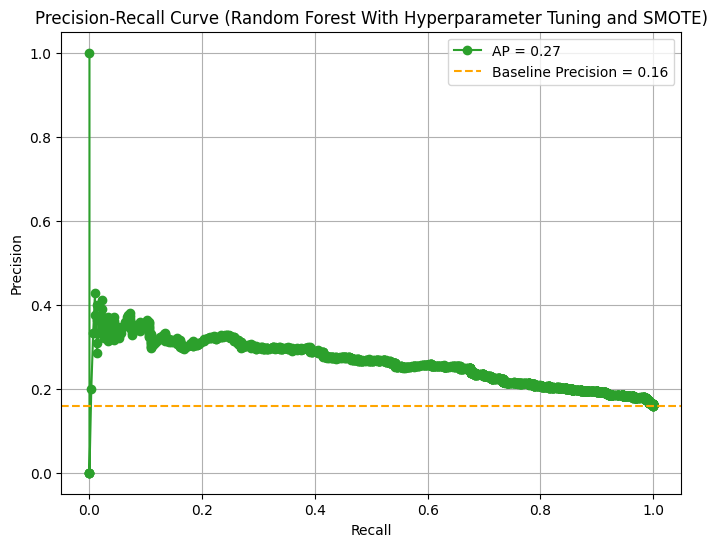

In [461]:
# compute precision-recall pairs
precision,recall,thresholds = precision_recall_curve(y_test,y_proba_rf_tuned_smote)

# compute average precision score (AUC of PR curve)
avg_precision_rf_tuned_smote = average_precision_score(y_test, y_proba_rf_tuned_smote)

# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall,precision,"-o",color='tab:green',label=f'AP = {avg_precision_rf_tuned_smote:.2f}')
plt.axhline(0.16,linestyle="dashed",color="orange",label="Baseline Precision = 0.16")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest With Hyperparameter Tuning and SMOTE)")
plt.legend()
plt.grid(True)
plt.show()

Interestingly, the AP has also increased by 0.01 with SMOTE despite having a significantly poorer recall. This highlights the need to prioritize particular performance metrics depending on the goal of your model. 

## Step 9. Balanced Random Forest
As one final effort (oof), we will try balanced random forest model to see if we can exceed our 60% recall that we achieved with our optimized random forest model with hyperparameter tuning (without SMOTE). The balanced random forest model is an ensemble method (like random forest) that is designed for imbalanced classification tasks like this one. Previously, we used SMOTE to oversample the minority class labels which works by interpolating between similar samples. In contrast, balanced random forest randomly undersamples the majority class to achieve balanced class labels for training. For this, we will use `imblearn.ensemble`'s `BalancedRandomForestClassifier()` function.

### 

In [295]:
brf = BalancedRandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1, sampling_strategy='all', replacement=True, bootstrap=False
)

brf.fit(X_train, y_train)


BalancedRandomForestClassifier(bootstrap=False, min_samples_leaf=10, n_jobs=-1,
                               random_state=42, replacement=True,
                               sampling_strategy='all')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


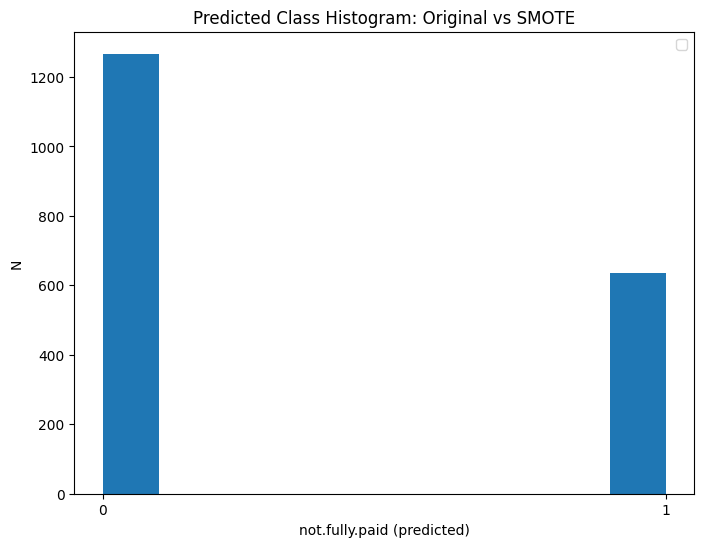

In [297]:
y_predict = brf.predict(X_test)

# create histogram
fig = plt.figure(figsize=(8,6))
plt.hist(y_pred)
plt.xticks([0, 1])
plt.xlabel('not.fully.paid (predicted)')
plt.ylabel('N')
plt.title('Predicted Class Histogram: Original vs SMOTE')
plt.show()

In [299]:
y_proba = brf.predict_proba(X_test)[:, 1]

In [301]:
# Print evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_proba))

Confusion Matrix:
[[1127  473]
 [ 140  164]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.79      1600
           1       0.26      0.54      0.35       304

    accuracy                           0.68      1904
   macro avg       0.57      0.62      0.57      1904
weighted avg       0.79      0.68      0.72      1904


ROC AUC Score:
0.6805777138157896


### Threshold Optimization

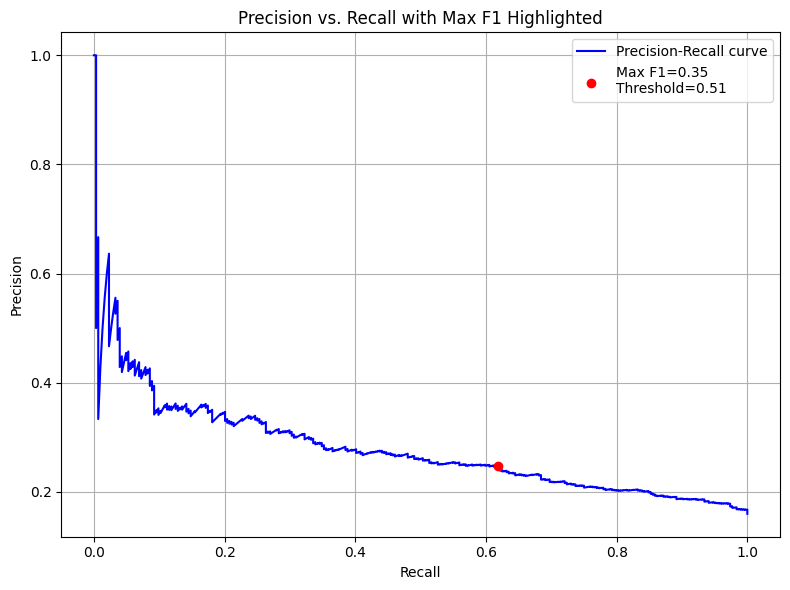

Best Threshold = 0.51, F1 Score = 0.35


In [323]:
# Step 2: Get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Step 3: Compute F1 scores for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

# Step 4: Find the index of the maximum F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

# Step 5: Plot precision vs recall
plt.figure(figsize=(8, 6))
plt.plot(recall,precision,label='Precision-Recall curve',color='blue')
plt.scatter(best_recall, best_precision, color='red', label=f'Max F1={best_f1:.2f}\nThreshold={best_threshold:.2f}', zorder=5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs. Recall with Max F1 Highlighted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Print best threshold
print(f"Best Threshold = {best_threshold:.2f}, F1 Score = {best_f1:.2f}")


### Step 6.5. Threshold Optimization
With the random forest model parameters fine-tuned to `n_estimators = 50`, `min_samples_split = 5`, `min_samples_leaf = 100`, `max_features = None`, `max_depth = 20`, `class_weight = 'balanced'`, and `bootstrap = False`, let's now optimize the probability threshold value for converting class probabilities into class labels. By default, `RandomForestClassifier()` uses a probability threshold of 0.5 (50%), which isn't necessarily optimal for datasets with significant class imbalances. We will try a range in thresholds to search for a maximum in model recall. 

In [303]:
# define thresholds from 0.01 to 0.99
thresholds = np.linspace(0.01, 0.99)

threshold_results_rf = []

# iterate through thresholds
for threshold in thresholds:
    # build and fit Balanced Random Forest model
    brf = BalancedRandomForestClassifier(
        n_estimators=50,
        min_samples_split=2,
        min_samples_leaf=100,
        max_features=None,
        max_depth=20,
        bootstrap=False,
        sampling_strategy='auto',  # or 'all' to match future behavior
        replacement=False,         # or True to match future behavior
        random_state=42
    )
    brf.fit(X_train, y_train)
    
    # predict probabilities
    y_proba = brf.predict_proba(X_test)[:, 1]
    
    # apply threshold
    y_predict = (y_proba > threshold).astype(int)

    # calculate metrics
    recall       = recall_score(y_test, y_predict, zero_division=0)
    precision    = precision_score(y_test, y_predict, zero_division=0)
    f1           = f1_score(y_test, y_predict, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_predict)
    auc_score    = roc_auc_score(y_test, y_proba)

    # append metrics
    threshold_results_rf.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f1_score': f1,
        'balanced_acc': balanced_acc,
        'auc_score': auc_score
    })

# compile results into a DataFrame
threshold_results_rf = pd.DataFrame(threshold_results_rf)


In [305]:
threshold_results_rf.head()

,threshold,recall,precision,f1_score,balanced_acc,auc_score
0,0.01,1.0,0.159664,0.275362,0.5,0.669421
1,0.03,1.0,0.159664,0.275362,0.5,0.669421
2,0.05,1.0,0.159664,0.275362,0.5,0.669421
3,0.07,1.0,0.159664,0.275362,0.5,0.669421
4,0.09,1.0,0.159664,0.275362,0.5,0.669421


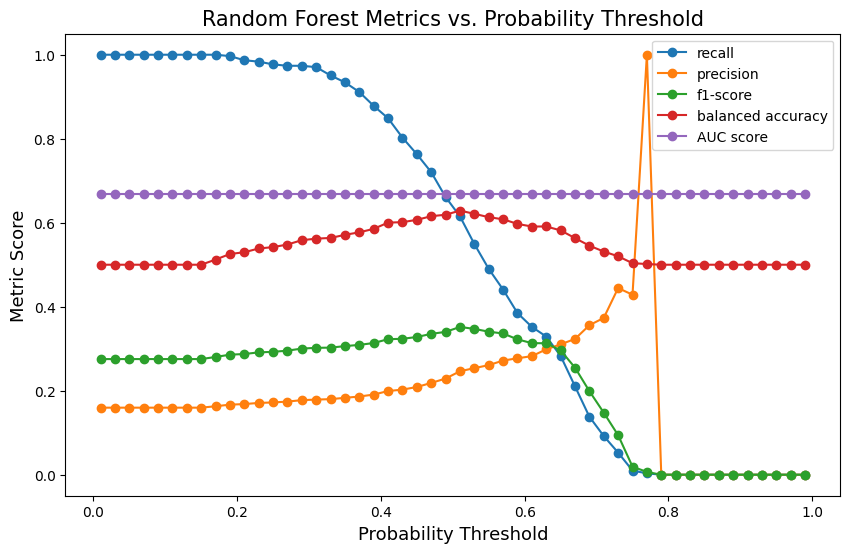

In [307]:
plt.figure(figsize=(10,6))
plt.plot(threshold_results_rf['threshold'],threshold_results_rf['recall'],'-o',label='recall')
plt.plot(threshold_results_rf['threshold'],threshold_results_rf['precision'],'-o',label='precision')
plt.plot(threshold_results_rf['threshold'],threshold_results_rf['f1_score'],'-o',label='f1-score')
plt.plot(threshold_results_rf['threshold'],threshold_results_rf['balanced_acc'],'-o',label='balanced accuracy')
plt.plot(threshold_results_rf['threshold'],threshold_results_rf['auc_score'],'-o',label='AUC score')
plt.xlabel('Probability Threshold',fontsize=13)
plt.ylabel('Metric Score',fontsize=13)
plt.title('Random Forest Metrics vs. Probability Threshold',fontsize=15)
plt.legend()
plt.savefig('./figures/balanced_random_forest_threshold_optimization.png',bbox_inches='tight')
plt.show()